#Wine Quality Prediction Assignment 2
##INF2008 Machine Learning Assignment

**Dataset:** winequalityN.csv (Red + White wines)
  - Source: https://www.kaggle.com/datasets/rajyellow46/wine-quality
    - Adapted from UCI Machine Learning Repository - Wine Quality Dataset
  - Collection: Portuguese "Vinho Verde" wines (red and white variants)
  - Period: Samples collected 2004-2007
  - Size: 6,497 samples (4,898 white, 1,599 red)

**Objective:** Predict wine quality using baseline machine learning models

**This notebook includes:**
1. Advanced Data Preparation & Pipeline Engineering
2. Champion Model Selection
3. Controlled Ablations & Tuning (The Champion)
4. Mechanical Failure Analysis
5. Decision Making

##Set-up Environment

Ensure that `winequalityN.csv` is loaded in the environment, or in the same directory as this notebook.

In [ ]:
#Imports
import pandas as pd
import numpy as np
#Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from imblearn.pipeline import Pipeline as ImbPipeline  # supports SMOTE
from imblearn.over_sampling import SMOTE
#Extension models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

#Initial seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
#Load Data
df = pd.read_csv('winequalityN.csv')
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Loaded: 6497 rows x 13 columns
Columns: ['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


##1. Advanced Data Preparation & Pipeline Engineering

Based on the Stage 1 findings, Stage 2 moves from procedural preprocessing toward a leakage-safe pipeline workflow.

**Before train-test split:**

1. Remove exact duplicate rows.
2. Encode the raw quality score into the 3-class business target.
3. Finalise the feature set by removing redundant predictors.

**After train-test split, inside formal pipelines only:**

1. Impute missing values.
2. Scale numeric features with `RobustScaler`.
3. One-hot encode the categorical `type` feature.
4. Fit the estimator as the final pipeline step.

This structure ensures that each fold in cross-validation learns preprocessing from the training data only.



###1.1 Remove Duplicate Rows
Method
- Duplicate rows were defined as records with identical values across all columns. These rows were removed before the train-test split.

Justification:
- Duplicate rows were identified as records with identical values across all columns and removed prior to the train-test split.

- Such exact duplicates are less likely to represent truly distinct wine samples and more likely to reflect repeated or duplicated records.

- If retained, these rows may over-represent common wine profiles and bias the model’s learning process.

- In addition, removing duplicates before splitting reduces the risk of identical observations appearing in both training and test sets, thereby preventing artificially inflated evaluation results.

Known Limitations:
- A limitation of this step is that 1,168 rows (17.98%) were removed. It is a substantial portion of the dataset. Some duplicates may reflect repeated measurements rather than erroneous entries. However, retaining exact duplicates would over-represent repeated wine profiles and may bias model learning and evaluation.

Sanity Check
- The class distribution of the original quality labels remained unchanged before and after duplicate removal.
- No duplicate rows remained after preprocessing.

Conclusion
- After duplicate removal, the dataset contains only unique wine records and is better suited for fair model training and evaluation.

In [ ]:
# 1.1 Remove duplicate rows before any split
df_raw = df.copy()

rows_before = len(df_raw)
duplicates_removed = df_raw.duplicated().sum()
quality_dist_before = df_raw['quality'].value_counts(normalize=True).sort_index()

df = df_raw.drop_duplicates().copy()
rows_after = len(df)
quality_dist_after = df['quality'].value_counts(normalize=True).sort_index()

summary_df = pd.DataFrame({
    'Metric': ['Rows before', 'Rows after', 'Duplicates removed', 'Remaining duplicates'],
    'Value': [
        rows_before,
        rows_after,
        f"{duplicates_removed} ({duplicates_removed / rows_before * 100:.2f}%)",
        int(df.duplicated().sum())
    ]
})

quality_check = pd.DataFrame({
    'Before %': (quality_dist_before * 100).round(2),
    'After %': (quality_dist_after * 100).round(2)
})
quality_check['Abs Diff %'] = (quality_check['Before %'] - quality_check['After %']).abs().round(2)

print(summary_df.to_string(index=False))
print('\nQuality distribution check after duplicate removal:')
print(quality_check)


              Metric         Value
         Rows before          6497
          Rows after          5329
  Duplicates removed 1168 (17.98%)
Remaining duplicates             0

Quality distribution check after duplicate removal:
         Before %  After %  Abs Diff %
quality                               
3            0.46     0.56        0.10
4            3.32     3.87        0.55
5           32.91    32.93        0.02
6           43.65    43.67        0.02
7           16.61    16.08        0.53
8            2.97     2.80        0.17
9            0.08     0.09        0.01


###1.2 Encode 3-Class Target (Low/Medium/High)
Encoding Rule
The original quality scores were grouped into three broader classes:
- Low: quality: 3–4
- Medium: quality: 5–6
- High: quality: 7–9

Justification:
- The original 7-class target is highly imbalanced, with very few samples at the extreme ends.

- Grouping the scores into 3 broader classes reduces sparsity and creates more meaningful prediction tiers for classification.

- In particular, the rarest original classes were poorly represented, with quality 3 containing only 30 samples (0.46%) and quality 9 containing only 5 samples (0.08%).

- Such low sample counts make it difficult for the model to learn stable decision boundaries for these extreme classes when treated separately.

- Collapsing the target into Low, Medium, and High therefore improves class support while preserving the ordinal meaning of wine quality.

Known Limitations:
- Although the target is less imbalanced after grouping, some imbalance still remains across the three new classes.

- This residual imbalance will be addressed later using SMOTE, applied only on the training data within the modelling pipeline.

In [ ]:
#Encode 3-Class Target
def categorize_quality(q):
  #3-4
  if q <= 4:
    return 'Low'
  #5-6
  elif q <= 6:
    return 'Medium'
  #7-9
  else:
    return 'High'

#Add 3-Class Target Column
df['quality_class'] = df['quality'].apply(categorize_quality)

#Map quality classes to integer labels (Low=0, Medium=1, High=2)
#Classifiers will treat this as a nominal label
QUALITY_MAP = {'Low': 0, 'Medium': 1, 'High': 2}
QUALITY_CLASSES = ['Low', 'Medium', 'High']

df['quality_encoded'] = df['quality_class'].map(QUALITY_MAP)

#Check new df state
print("Original quality distribution (7 classes):")
print(df['quality'].value_counts().sort_index())

print("\nLabel encoding map:")
for cls, code in QUALITY_MAP.items():
    print(f"  '{cls}' -> {code}")

grouped_dist = df['quality_class'].value_counts().reindex(QUALITY_CLASSES, fill_value=0)

summary_3class = pd.DataFrame({
    "Class": QUALITY_CLASSES,
    "Encoded Label": [QUALITY_MAP[c] for c in QUALITY_CLASSES],
    "Count": [grouped_dist[c] for c in QUALITY_CLASSES],
    "Percentage": [grouped_dist[c] / len(df) * 100 for c in QUALITY_CLASSES]
})

summary_3class["Percentage"] = summary_3class["Percentage"].map(lambda x: f"{x:.2f}%")
summary_3class

Original quality distribution (7 classes):
quality
3      30
4     206
5    1755
6    2327
7     857
8     149
9       5
Name: count, dtype: int64

Label encoding map:
  'Low' -> 0
  'Medium' -> 1
  'High' -> 2


,Class,Encoded Label,Count,Percentage
0,Low,0,236,4.43%
1,Medium,1,4082,76.60%
2,High,2,1011,18.97%


### 1.2.1 Stage 1 Architecture Decision: Combined vs Separate Models

Stage 1 explored separate models for red and white wines, motivated by the observation that both wine types have different chemical profiles and different correlations between features and quality. That experiment found that separate models did not consistently outperform the combined model, and the Stage 1 conclusion flagged further experimentation as a Stage 2 direction.

Stage 2 adopts a single combined model for the following reasons. First, the Stage 2 pipeline uses OneHotEncoder on the wine type column, which allows the model to learn wine-type-specific patterns within a single combined model without discarding type information. Second, the Stage 2 preprocessing uses RobustScaler instead of StandardScaler, which addresses the finding from Stage 1 that scaling negatively impacted the separate red and white models. Third, combining both types into one model produces a larger training set, which benefits the minority Low class that had very few samples in the red wine subset alone. The decision to use a combined model is therefore justified by the pipeline improvements in Stage 2, rather than being an oversight of the Stage 1 findings.

### 1.3 Finalise the Feature Set

**Justification**

The correlation matrix printed in the cell below supports the following removal decisions.

`free sulfur dioxide` is removed for two reasons. First, it is strongly correlated with `total sulfur dioxide` (r = 0.72 on the full dataset after deduplication), making it partially redundant as a predictor. Second, its correlation with `quality` is weak (r = -0.05), meaning it contributes little independent signal about wine quality. Retaining it alongside `total sulfur dioxide` would add noise without meaningful predictive value.

`residual sugar` is removed because it is highly correlated with `density` (r = 0.55 on the full dataset), reflecting the physical relationship that dissolved sugar increases liquid density. Since `density` is retained and carries a stronger correlation with `quality` (r = -0.31 vs r = -0.10 for `residual sugar`), retaining both would introduce redundancy without improving class separation. The Stage 1 correlation analysis also identified the `residual sugar` and `density` pair as the only feature pair exceeding the 0.5 threshold in the white wine subset.

**Outlier treatment**

Outliers are retained because they may represent valid extreme wine profiles such as high-alcohol fortified wines or high-sugar dessert wines, rather than measurement errors. This is consistent with the Stage 1 decision and the domain assumptions documented in Stage 1 Section 2.3.

**Note on the correlation values**

The exact values printed below are computed after duplicate removal, which is the correct state of the data at this point in the pipeline. They may differ slightly from the Stage 1 values, which were computed on the raw dataset before deduplication.

In [ ]:
# Support for feature removal decisions
corr = df[['free sulfur dioxide', 'total sulfur dioxide', 'residual sugar', 'density', 'quality']].corr()
print("Correlation matrix for candidate removal features:")
print(corr.round(3))

Correlation matrix for candidate removal features:
                      free sulfur dioxide  total sulfur dioxide  \
free sulfur dioxide                 1.000                 0.721   
total sulfur dioxide                0.721                 1.000   
residual sugar                      0.400                 0.488   
density                             0.007                 0.007   
quality                             0.054                -0.050   

                      residual sugar  density  quality  
free sulfur dioxide            0.400    0.007    0.054  
total sulfur dioxide           0.488    0.007   -0.050  
residual sugar                 1.000    0.522   -0.057  
density                        0.522    1.000   -0.327  
quality                       -0.057   -0.327    1.000  


In [ ]:
# 1.3 Finalise feature set

df_model = df.copy()

cols_to_drop = ["free sulfur dioxide", "residual sugar"]
df_model = df_model.drop(columns=cols_to_drop)

print("Remaining columns:")
print(df_model.columns.tolist())
print("\nShape after feature removal:", df_model.shape)

Remaining columns:
['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'quality_class', 'quality_encoded']

Shape after feature removal: (5329, 13)


### 1.3.1 Bivariate Feature-Target Visualisations

**Purpose**  
While correlation matrices show linear associations between features, they do not reveal how individual features distribute across the target classes. Box plots provide a direct view of which features discriminate between Low, Medium, and High quality wines, supporting the feature-selection decisions made above.

**Features Shown**  
- `alcohol`: strongest single predictor of quality class in prior correlation analysis.
- `volatile acidity`: negatively associated with quality; high values indicate wine faults.
- `density`: retained despite correlation with residual sugar (which was dropped); shown here to confirm it still separates classes.
- `sulphates`: moderate positive relationship with quality.

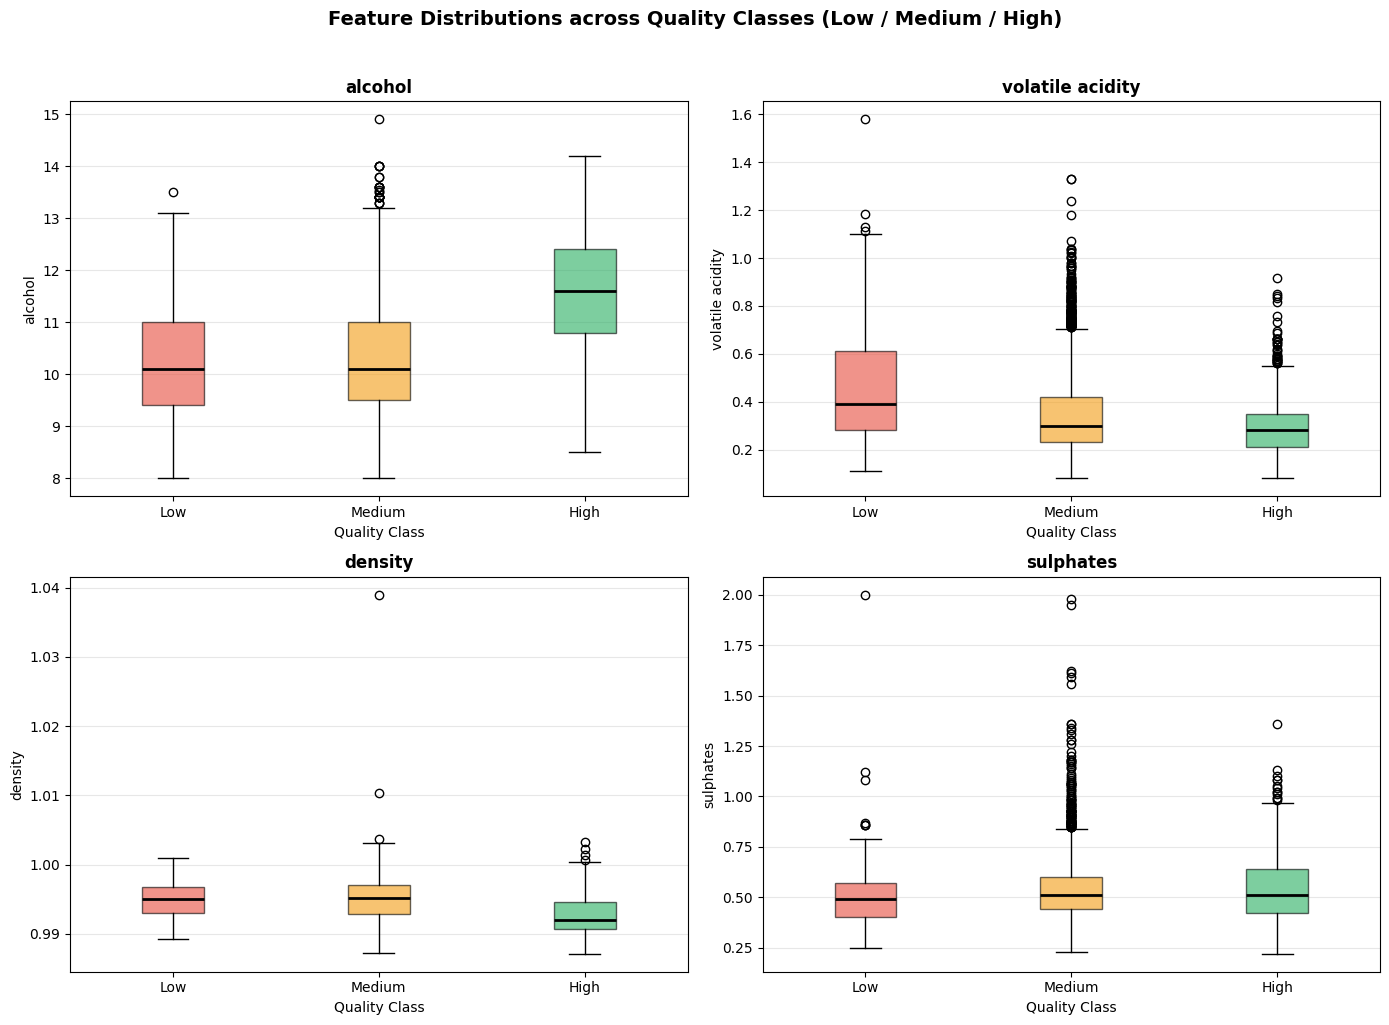

Key observations:
- Alcohol shows the clearest class separation: High-quality wines have notably higher alcohol.
- Volatile acidity is higher for Low-quality wines, confirming its role as a fault indicator.
- Density overlaps more across classes but Low wines tend toward higher density.
- Sulphates show moderate separation, with High-quality wines slightly elevated.


In [ ]:
# 1.3.1 Bivariate feature-target box plots
import matplotlib.pyplot as plt

# Use the quality_class column for readable labels
plot_features = ['alcohol', 'volatile acidity', 'density', 'sulphates']
class_order = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions across Quality Classes (Low / Medium / High)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, feature in zip(axes.ravel(), plot_features):
    data_to_plot = [df.loc[df['quality_class'] == cls, feature].dropna()
                    for cls in class_order]

    bp = ax.boxplot(data_to_plot, labels=class_order, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))

    colors = ['#e74c3c', '#f39c12', '#27ae60']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(feature, fontsize=12, fontweight='bold')
    ax.set_xlabel('Quality Class')
    ax.set_ylabel(feature)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Alcohol shows the clearest class separation: High-quality wines have notably higher alcohol.")
print("- Volatile acidity is higher for Low-quality wines, confirming its role as a fault indicator.")
print("- Density overlaps more across classes but Low wines tend toward higher density.")
print("- Sulphates show moderate separation, with High-quality wines slightly elevated.")

###1.4 Define X and Y

**Purpose**  
This step separates the predictor variables from the target variable used for classification.

**Definition**
- `X` contains the input features used by the model.
- `y` contains the target labels to be predicted.

**Implementation**
- The target variable is defined as `quality_encoded`, where:
  - `Low` = 0
  - `Medium` = 1
  - `High` = 2
- The columns `quality`, `quality_class`, and `quality_encoded` are excluded from `X` to prevent target leakage.

**Reasoning**
- `quality` and its transformed versions are derived from the same target outcome and must not be used as predictors.
- Separating `X` and `y` at this stage prepares the dataset for a leakage-safe train-test split in the next step.

In [ ]:
# 1.4 Define X and y

target_col = "quality_encoded"
target_related_cols = ["quality", "quality_class", "quality_encoded"]

X = df_model.drop(columns=target_related_cols)
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution (encoded):")
print(y.value_counts().sort_index())

print("\nTarget distribution (proportion):")
print(y.value_counts(normalize=True).sort_index())

target_summary = y.value_counts().sort_index().rename_axis("Encoded Class").reset_index(name="Count")
target_summary["Proportion"] = (target_summary["Count"] / len(y) * 100).round(2).astype(str) + "%"

target_summary

X shape: (5329, 10)
y shape: (5329,)

Feature columns:
['type', 'fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target distribution (encoded):
quality_encoded
0     236
1    4082
2    1011
Name: count, dtype: int64

Target distribution (proportion):
quality_encoded
0    0.044286
1    0.765997
2    0.189717
Name: proportion, dtype: float64


,Encoded Class,Count,Proportion
0,0,236,4.43%
1,1,4082,76.6%
2,2,1011,18.97%


### 1.5 Stratified Train-Test Split

**Purpose**  
The dataset is split into training and test sets so that model development and final evaluation are performed on separate data.

**Method**
- An 80/20 train-test split is used.
- Stratification is applied based on `y` so that the class proportions of Low, Medium, and High quality wines are preserved in both subsets.
- A fixed random state is used to ensure reproducibility.

**Justification**
- The encoded 3-class target remains imbalanced, especially for the Low class.
- A stratified split helps ensure that minority and majority classes are represented proportionally in both the training and test sets.
- The test set is reserved for final evaluation only and is not used during model selection or cross-validation.

**Conclusion**
- The 80/20 stratified split preserved the class distribution of the encoded target across both training and test sets. This ensures that model development is performed on a representative training set, while the held-out test set remains suitable for unbiased final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split

# 1.5 Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution (count):")
print(y_train.value_counts().sort_index())

print("\nTraining target distribution (proportion):")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution (count):")
print(y_test.value_counts().sort_index())

print("\nTest target distribution (proportion):")
print(y_test.value_counts(normalize=True).sort_index())
split_summary = pd.DataFrame({
    "Class": [0, 1, 2],
    "Train Count": y_train.value_counts().sort_index().values,
    "Train Proportion": (y_train.value_counts(normalize=True).sort_index().values * 100).round(2),
    "Test Count": y_test.value_counts().sort_index().values,
    "Test Proportion": (y_test.value_counts(normalize=True).sort_index().values * 100).round(2),
})

split_summary["Train Proportion"] = split_summary["Train Proportion"].astype(str) + "%"
split_summary["Test Proportion"] = split_summary["Test Proportion"].astype(str) + "%"

split_summary

X_train shape: (4263, 10)
X_test shape: (1066, 10)
y_train shape: (4263,)
y_test shape: (1066,)

Training target distribution (count):
quality_encoded
0     189
1    3265
2     809
Name: count, dtype: int64

Training target distribution (proportion):
quality_encoded
0    0.044335
1    0.765893
2    0.189772
Name: proportion, dtype: float64

Test target distribution (count):
quality_encoded
0     47
1    817
2    202
Name: count, dtype: int64

Test target distribution (proportion):
quality_encoded
0    0.044090
1    0.766417
2    0.189493
Name: proportion, dtype: float64


,Class,Train Count,Train Proportion,Test Count,Test Proportion
0,0,189,4.43%,47,4.41%
1,1,3265,76.59%,817,76.64%
2,2,809,18.98%,202,18.95%


### 1.6 Build Leakage-Safe Preprocessing Pipeline

**Purpose**  
This step defines the preprocessing workflow that will be applied to the training data before modelling.

**Feature Types**
- `type` is treated as a categorical feature.
- All remaining predictors are treated as numerical features.

**Preprocessing Design**
- Numerical features are imputed using the median and scaled using `RobustScaler`.
- Categorical features are imputed using the most frequent value and encoded using `OneHotEncoder`.

**Justification**
- Median imputation is used because it is less sensitive to extreme values than mean imputation.
- `RobustScaler` is used instead of `StandardScaler` for two reasons. First, outliers are retained in this dataset as they represent valid extreme wine profiles, and `RobustScaler` is less sensitive to outliers than `StandardScaler` because it scales using the median and interquartile range rather than the mean and standard deviation. Second, Stage 1 found that `StandardScaler` negatively impacted performance on the separated red and white wine models, suggesting that the wine chemistry features have distributions that do not scale well under the mean-and-variance assumption. `RobustScaler` is a more principled choice for this feature space.
- `OneHotEncoder` is used for `type` so that the model can use wine type information without imposing an artificial numeric ordering.
- The preprocessing steps are defined as a pipeline so they can later be fitted only on the training folds during cross-validation, preventing data leakage.

**Important Note**
- The preprocessing object is defined here but not be fitted on the full dataset.
- It will be incorporated into the modelling pipeline later so that each training fold is transformed consistently and safely.

**Conclusion**
A column-wise preprocessing pipeline was defined to handle numerical and categorical features appropriately. This structure ensures that all transformations can later be applied consistently within cross-validation without leaking information from validation or test data.

In [ ]:
# 1.6 Build leakage-safe preprocessing and model pipelines
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor():
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", build_one_hot_encoder())
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

def make_model_pipeline(estimator):
    return Pipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("model", estimator)
    ])

model_pipelines = {
    "Logistic Regression": make_model_pipeline(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    ),
    "K-Nearest Neighbors": make_model_pipeline(
        KNeighborsClassifier()
    ),
    "Random Forest": make_model_pipeline(
        RandomForestClassifier(
              random_state=RANDOM_STATE,
              n_jobs=1                    # avoids nested parallelism
            )
    ),
    "LightGBM": make_model_pipeline(
      LGBMClassifier(
          objective="multiclass",
          num_class=3,
          metric="multi_logloss",
          class_weight="balanced",      # handles Low/High minority classes natively
          random_state=RANDOM_STATE,
          n_jobs=1,                     # avoids nested parallelism with cross_validate
          verbose=-1                    # suppress training logs during CV
      )
    )
}

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("\nDefined formal model pipelines:")
for model_name, pipeline in model_pipelines.items():
    print(f"- {model_name}: {list(pipeline.named_steps.keys())}")

Categorical columns: ['type']
Numeric columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Defined formal model pipelines:
- Logistic Regression: ['preprocessor', 'model']
- K-Nearest Neighbors: ['preprocessor', 'model']
- Random Forest: ['preprocessor', 'model']
- LightGBM: ['preprocessor', 'model']


## 2. Champion Model Selection

**Purpose**

This section compares a small number of distinct model families under the same preprocessing workflow and selects one champion model for the later ablation experiments.

**Metric change from Stage 1**

Stage 1 used overall accuracy as the primary metric, with a target of beating the dummy classifier baseline of approximately 76.6%.

Accuracy was appropriate in Stage 1 because the goal was simply to establish feasibility above a naive baseline. Stage 2 switches to Macro F1 as the primary metric for champion selection. This change is justified because accuracy is misleading when classes are imbalanced: a model that predicts Medium for most samples can achieve high accuracy while completely failing on the Low and High classes. Macro F1 gives equal weight to all three classes regardless of their size, which better reflects the business need to detect low-quality and high-quality wines reliably, not just classify the majority class correctly.

**Candidate Model Families**

Four candidates are evaluated, covering three distinct algorithmic families:

- `Logistic Regression`: a linear model that tests whether the 3-class target can be separated with mostly linear boundaries. Included as the linear family representative.
- `K-Nearest Neighbors`: a distance-based model that may capture local wine profiles in the feature space after scaling. Included as the distance-based family representative.
- `Random Forest`: a bagging ensemble of decision trees that can model non-linear relationships and feature interactions. Included as the tree-based ensemble representative.
- `LightGBM`: a gradient boosting ensemble that also models non-linear relationships but builds trees sequentially rather than in parallel, and supports native class weighting for imbalanced targets. Included as a second tree-based ensemble representative to compare bagging against boosting within the same algorithmic family.

LightGBM is a gradient boosting model, hence it still lies within the scope of Assignment 2.

**Evaluation Protocol**
- All models are trained only through the same formal pipeline structure defined in Section 1.
- 5-fold StratifiedKFold is applied on X_train and y_train only.
- The hold-out test set remains untouched until final evaluation.
- A single fixed random seed (RANDOM_STATE = 42) is used for all splits and models. Model stability is assessed through the standard deviation across the 5 CV folds. Note: Stage 1 used multiple random seeds and reported averaged accuracy, which introduced ambiguity about which specific model constituted the baseline. Stage 2 replaces this with single-seed cross-validation for transparency, while the fold-to-fold variance naturally captures the stability that the multi-seed approach intended to measure.

**Decision Rule**
- The champion is selected primarily by f1_macro.
- balanced_accuracy is used as a secondary check.
- accuracy is reported for context only.

### 2.1 Choose the Primary CV Metric

**Purpose**  
This step defines the metric used to compare candidate models fairly.

**Chosen Metric**
- Primary metric: `f1_macro`
- Secondary metrics: `balanced_accuracy`, `accuracy`

**Justification**
- The dataset remains imbalanced even after grouping quality into Low, Medium, and High, so plain accuracy can still look deceptively strong.
- `f1_macro` gives equal importance to all three classes and therefore penalizes models that mainly predict the majority `Medium` class well.
- Because `f1_macro` combines precision and recall, it better reflects the business need to reduce both missed low-quality wines and incorrect premium classifications.
- `balanced_accuracy` is retained as a secondary metric because it checks whether recall is distributed more evenly across classes.

**Conclusion**
- `f1_macro` is the most defensible primary metric for champion selection in this 3-class imbalanced problem.


### 2.2 Compare candidate models with 5-fold cross-validation

In [ ]:
# 2.2 Compare candidate models with 5-fold cross-validation
primary_metric = "f1_macro"
primary_metric_label = "Macro F1"

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "accuracy": "accuracy"
}

cv_rows = []
cv_raw_scores = {}

# Note: n_jobs=-1 parallelises cross-validate folds.
# LightGBM is set to n_jobs=1 internally to avoid nested parallelism conflicts.
for model_name, pipeline in model_pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_raw_scores[model_name] = scores
    row = {"Model": model_name}

    for metric_name in scoring:
        metric_values = scores[f"test_{metric_name}"]
        row[f"{metric_name}_mean"] = metric_values.mean()
        row[f"{metric_name}_std"] = metric_values.std()
        row[f"{metric_name}_summary"] = f"{metric_values.mean():.3f} +/- {metric_values.std():.3f}"

    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values(
    by=[f"{primary_metric}_mean", "balanced_accuracy_mean", f"{primary_metric}_std"],
    ascending=[False, False, True]
).reset_index(drop=True)

cv_comparison_table = cv_results_df[[
    "Model",
    "f1_macro_summary",
    "balanced_accuracy_summary",
    "accuracy_summary"
]].rename(columns={
    "f1_macro_summary": "Macro F1 (mean +/- std)",
    "balanced_accuracy_summary": "Balanced Accuracy (mean +/- std)",
    "accuracy_summary": "Accuracy (mean +/- std)"
})

cv_rank_detail_table = cv_results_df[[
    "Model",
    "f1_macro_mean",
    "f1_macro_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "accuracy_mean",
    "accuracy_std"
]].copy()

cv_rank_detail_table.insert(0, "Rank (Macro F1)", range(1, len(cv_rank_detail_table) + 1))
cv_rank_detail_table[[
    "f1_macro_mean",
    "f1_macro_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "accuracy_mean",
    "accuracy_std"
]] = cv_rank_detail_table[[
    "f1_macro_mean",
    "f1_macro_std",
    "balanced_accuracy_mean",
    "balanced_accuracy_std",
    "accuracy_mean",
    "accuracy_std"
]].round(3)

print("Cross-validation comparison table:")
cv_results_df

Cross-validation comparison table:


,Model,f1_macro_mean,f1_macro_std,f1_macro_summary,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_summary,accuracy_mean,accuracy_std,accuracy_summary
0,LightGBM,0.524710,0.028666,0.525 +/- 0.029,0.533415,0.026988,0.533 +/- 0.027,0.736576,0.012988,0.737 +/- 0.013
1,K-Nearest Neighbors,0.487727,0.021731,0.488 +/- 0.022,0.466154,0.015221,0.466 +/- 0.015,0.780901,0.009977,0.781 +/- 0.010
2,Random Forest,0.452666,0.017575,0.453 +/- 0.018,0.437591,0.011846,0.438 +/- 0.012,0.792868,0.004702,0.793 +/- 0.005
3,Logistic Regression,0.429985,0.003711,0.430 +/- 0.004,0.417224,0.002153,0.417 +/- 0.002,0.778558,0.003004,0.779 +/- 0.003


### 2.3 Comparison of Candidate Models

**Purpose**  
This visualisation complements the comparison table and makes the trade-offs between the models easier to see.

**How to read the figures**
- The grouped bar chart compares the mean cross-validation scores for all three reported metrics.
- The horizontal bar chart focuses on the primary metric only and adds error bars to show fold-to-fold variability.
- If a model has higher accuracy but weaker Macro F1, that suggests it may be benefiting more from the majority class than from balanced multi-class performance.


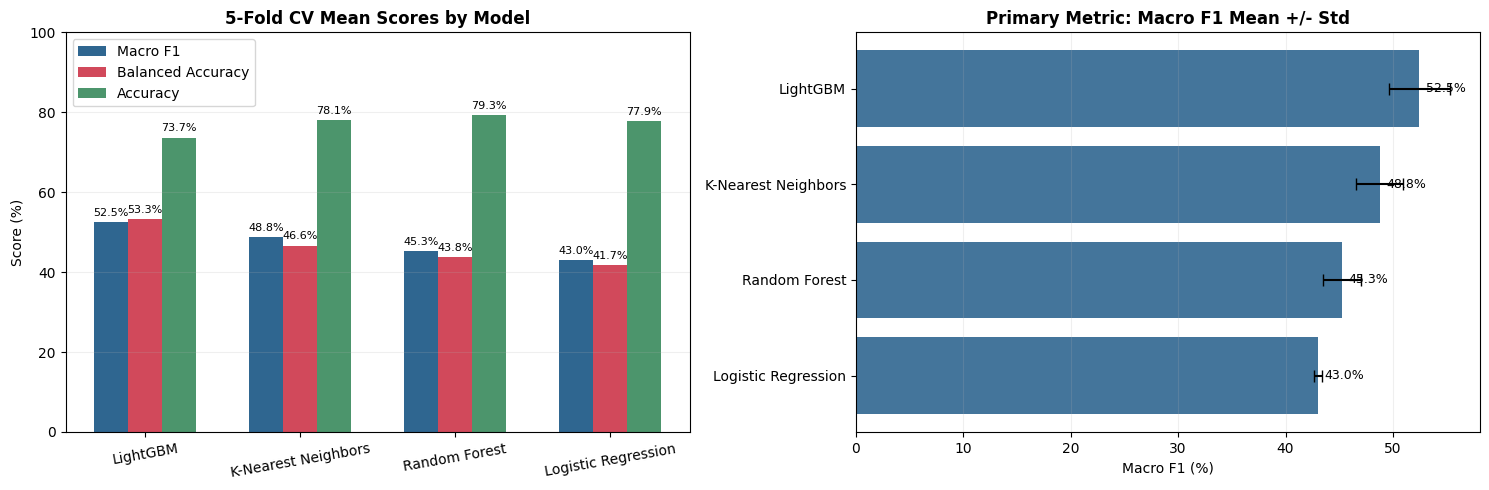

In [ ]:
# 2.3 comparison of candidate models
plot_df = cv_results_df.copy()
model_order = plot_df["Model"].tolist()
metric_specs = [
    ("f1_macro_mean", "Macro F1", "#2F6690"),
    ("balanced_accuracy_mean", "Balanced Accuracy", "#D1495B"),
    ("accuracy_mean", "Accuracy", "#4C956C")
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(model_order))
width = 0.22

for idx, (metric_col, metric_label, color) in enumerate(metric_specs):
    values = plot_df[metric_col].to_numpy() * 100
    bars = axes[0].bar(x + (idx - 1) * width, values, width=width, label=metric_label, color=color)
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate(
            f"{height:.1f}%",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8
        )

axes[0].set_title("5-Fold CV Mean Scores by Model", fontweight="bold")
axes[0].set_ylabel("Score (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_order, rotation=10)
axes[0].set_ylim(0, 100)
axes[0].legend(loc="upper left")
axes[0].grid(axis="y", alpha=0.2)

macro_plot = plot_df.sort_values("f1_macro_mean", ascending=True)
axes[1].barh(
    macro_plot["Model"],
    macro_plot["f1_macro_mean"] * 100,
    xerr=macro_plot["f1_macro_std"] * 100,
    color="#2F6690",
    alpha=0.9,
    ecolor="black",
    capsize=4
)
axes[1].set_title("Primary Metric: Macro F1 Mean +/- Std", fontweight="bold")
axes[1].set_xlabel("Macro F1 (%)")
axes[1].grid(axis="x", alpha=0.2)

for y_pos, value in enumerate(macro_plot["f1_macro_mean"] * 100):
    axes[1].text(value + 0.6, y_pos, f"{value:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()


### 2.4 Key Findings from the Cross-Validation Comparison

**Purpose**  
This step translates the table and charts into model-selection reasoning.

**Interpretation focus**
- Which model performs best on the primary metric?
- Is the best model also stable across folds?
- Does any model look better only because of raw accuracy?
- Is the difference large enough to justify selecting one champion for Section 3?



In [ ]:
# 2.4 Key findings from the cross-validation comparison
best_macro_row = cv_results_df.loc[0]
runner_up_row = cv_results_df.loc[1]
best_accuracy_row = cv_results_df.sort_values(["accuracy_mean", "f1_macro_mean"], ascending=False).iloc[0]
lowest_macro_row = cv_results_df.iloc[-1]

macro_gap = best_macro_row["f1_macro_mean"] - runner_up_row["f1_macro_mean"]
balanced_gap = best_macro_row["balanced_accuracy_mean"] - runner_up_row["balanced_accuracy_mean"]

print("KEY FINDINGS FROM CROSS-VALIDATION")
print(f"1. {best_macro_row['Model']} ranked first on the primary metric with Macro F1 = {best_macro_row['f1_macro_summary']}.")
print(f"   It outperformed the runner-up ({runner_up_row['Model']}) by {macro_gap:.3f} Macro F1 points.")
print(f"2. {best_macro_row['Model']} also led the comparison in more balanced class performance, with a balanced accuracy advantage of {balanced_gap:.3f} over the runner-up.")

if best_accuracy_row['Model'] != best_macro_row['Model']:
    print(f"3. {best_accuracy_row['Model']} achieved the highest raw accuracy ({best_accuracy_row['accuracy_summary']}), but it was not the best all-round model.")
    print("   This confirms that accuracy alone would give a less reliable decision for this imbalanced 3-class problem.")
else:
    print(f"3. {best_macro_row['Model']} also achieved the highest raw accuracy, so the primary and secondary views are aligned.")

print(f"4. {lowest_macro_row['Model']} ranked last on Macro F1, suggesting that its current decision rule is least effective for balanced prediction across Low, Medium, and High.")
print("5. The separation between the top model and the alternatives is large enough to justify selecting a single champion before moving to controlled ablations.")



KEY FINDINGS FROM CROSS-VALIDATION
1. LightGBM ranked first on the primary metric with Macro F1 = 0.525 +/- 0.029.
   It outperformed the runner-up (K-Nearest Neighbors) by 0.037 Macro F1 points.
2. LightGBM also led the comparison in more balanced class performance, with a balanced accuracy advantage of 0.067 over the runner-up.
3. Random Forest achieved the highest raw accuracy (0.793 +/- 0.005), but it was not the best all-round model.
   This confirms that accuracy alone would give a less reliable decision for this imbalanced 3-class problem.
4. Logistic Regression ranked last on Macro F1, suggesting that its current decision rule is least effective for balanced prediction across Low, Medium, and High.
5. The separation between the top model and the alternatives is large enough to justify selecting a single champion before moving to controlled ablations.


### 2.4.1 Per-Class Metric Check Against Business Success Criteria

**Purpose**  
The Business Understanding phase (Stage 1) defined secondary success criteria:
- **Low-class recall > 70%** , ensuring most defective wines are caught.
- **High-class precision > 75%** , ensuring premium labels are trustworthy.

This step extracts those specific metrics from the cross-validation predictions of the champion model and checks whether the targets are met.

In [ ]:
# 2.4.1 Per-class metric check against business success criteria
from sklearn.metrics import classification_report

# Generate out-of-fold predictions for the top-ranked (champion) model
champion_name = cv_results_df.loc[0, "Model"]
champion_pipe = model_pipelines[champion_name]

y_pred_cv = cross_val_predict(
    champion_pipe, X_train, y_train,
    cv=cv, method="predict", n_jobs=-1
)

report = classification_report(
    y_train, y_pred_cv,
    target_names=["Low", "Medium", "High"],
    output_dict=True
)

low_recall = report["Low"]["recall"]
high_precision = report["High"]["precision"]

LOW_RECALL_TARGET = 0.70
HIGH_PRECISION_TARGET = 0.75

print(f"Champion model: {champion_name}")
print(f"{'='*55}")
print(f"  Low-class recall:    {low_recall:.3f}  (target > {LOW_RECALL_TARGET:.2f})  {'PASS' if low_recall > LOW_RECALL_TARGET else 'FAIL'}")
print(f"  High-class precision: {high_precision:.3f}  (target > {HIGH_PRECISION_TARGET:.2f})  {'PASS' if high_precision > HIGH_PRECISION_TARGET else 'FAIL'}")
print(f"{'='*55}")
print()

# Show the full per-class report for all candidate models
print("Full per-class CV report for champion model:")
print(classification_report(y_train, y_pred_cv, target_names=["Low", "Medium", "High"]))

if low_recall <= LOW_RECALL_TARGET:
    print(f">> WARNING: Low recall ({low_recall:.3f}) is below the 70% target.")
    print("   This will be addressed in Section 3 (ablations) and Section 5 (threshold tuning).")
if high_precision <= HIGH_PRECISION_TARGET:
    print(f">> WARNING: High precision ({high_precision:.3f}) is below the 75% target.")
    print("   Threshold tuning in Section 5 may help improve this.")

Champion model: LightGBM
  Low-class recall:    0.190  (target > 0.70)  FAIL
  High-class precision: 0.463  (target > 0.75)  FAIL

Full per-class CV report for champion model:
              precision    recall  f1-score   support

         Low       0.26      0.19      0.22       189
      Medium       0.85      0.80      0.83      3265
        High       0.46      0.61      0.53       809

    accuracy                           0.74      4263
   macro avg       0.53      0.53      0.52      4263
weighted avg       0.75      0.74      0.74      4263

>> WARNING: Low recall (0.190) is below the 70% target.
   This will be addressed in Section 3 (ablations) and Section 5 (threshold tuning).
>> WARNING: High precision (0.463) is below the 75% target.
   Threshold tuning in Section 5 may help improve this.


### 2.4.2 Interpreting the Recall Gap

The per-class check above is likely to show that Low-class recall falls below the 70% business target at the default 0.5 decision threshold. This is a known limitation of the model at the model level and is expected given the class imbalance in the dataset even after 3-class grouping.

Two complementary responses are taken across the rest of this notebook.

**At the model level (Section 3):** Four controlled ablations are run on the LightGBM champion to test whether model-side changes (more estimators, lower learning rate, restricted tree depth, SMOTE oversampling) can improve minority-class performance. If none of these ablations meaningfully improve Macro F1, the baseline configuration is retained.

**At the decision layer (Section 5):** Regardless of the model-level outcome, the Low-class decision threshold is lowered below 0.5 so that the model flags more wines for low-quality review. This directly increases Low-class recall at the cost of some additional false positives, which is the correct trade-off given the business context: missing a defective wine is more costly than over-flagging an acceptable one for review.

This separation between model-level and decision-level fixes is intentional. It reflects the CRISP-DM principle that a model's raw output and the business decision derived from it are two distinct concerns.

### 2.5 Declare the Champion Model

**Purpose**  
This step names a single model to carry forward into Section 3.

**Selection Method**
- Rank all candidates by the primary metric (`f1_macro`).
- Use `balanced_accuracy` as a secondary check when models are close.
- Prefer the model with the stronger mean score while still monitoring score stability through the standard deviation.

**Why only one champion?**
- Stage 2 requires controlled experimentation, not broad brute-force search.
- Restricting later ablations to one champion model keeps the experiments disciplined and interpretable.
- This also ensures that the hold-out test set is not repeatedly consulted during model development.


In [ ]:
# 2.5 Select the champion based on the CV table
champion_model_name = cv_results_df.loc[0, "Model"]
champion_pipeline = model_pipelines[champion_model_name]
champion_row = cv_results_df.loc[0]

champion_summary = pd.DataFrame({
    "Selection Item": [
        "Primary selection metric",
        "Champion model",
        "Runner-up model",
        "Champion Macro F1",
        "Champion Balanced Accuracy",
        "Champion Accuracy"
    ],
    "Value": [
        primary_metric_label,
        champion_model_name,
        cv_results_df.loc[1, 'Model'],
        champion_row['f1_macro_summary'],
        champion_row['balanced_accuracy_summary'],
        champion_row['accuracy_summary']
    ]
})

print(f"Primary selection metric: {primary_metric_label}")
print(f"Champion model: {champion_model_name}")
print(f"Macro F1: {champion_row['f1_macro_summary']}")
print(f"Balanced Accuracy: {champion_row['balanced_accuracy_summary']}")
print(f"Accuracy: {champion_row['accuracy_summary']}")

if len(cv_results_df) > 1:
    runner_up = cv_results_df.loc[1]
    best_accuracy_model = cv_results_df.sort_values(["accuracy_mean", "f1_macro_mean"], ascending=False).iloc[0]
    primary_gap = champion_row['f1_macro_mean'] - runner_up['f1_macro_mean']
    print(f"Gap over runner-up in Macro F1: {primary_gap:.3f}")
    print(f"Runner-up model: {runner_up['Model']}")
    if best_accuracy_model['Model'] != champion_model_name:
        print(f"Highest raw accuracy model: {best_accuracy_model['Model']}")

print("\nSelection rationale:")
print("- All candidates used the same preprocessing pipeline, so this was a fair comparison.")
print(f"- {champion_model_name} achieved the highest cross-validated {primary_metric_label}.")
print("- The champion was chosen for more balanced 3-class performance, not just for majority-class accuracy.")
print("- The hold-out test set remains untouched for later final evaluation.")



Primary selection metric: Macro F1
Champion model: LightGBM
Macro F1: 0.525 +/- 0.029
Balanced Accuracy: 0.533 +/- 0.027
Accuracy: 0.737 +/- 0.013
Gap over runner-up in Macro F1: 0.037
Runner-up model: K-Nearest Neighbors
Highest raw accuracy model: Random Forest

Selection rationale:
- All candidates used the same preprocessing pipeline, so this was a fair comparison.
- LightGBM achieved the highest cross-validated Macro F1.
- The champion was chosen for more balanced 3-class performance, not just for majority-class accuracy.
- The hold-out test set remains untouched for later final evaluation.


## 3. Controlled Ablations & Tuning (Champion)

**Purpose**  
This section performs a small number of controlled experiments on the chosen champion model only. The goal is not to brute-force performance, but to test specific hypotheses about why the champion may improve or fail.

**Champion entering Section 3**
- Model family: `LightGBM`
- Baseline configuration from Section 2: default `LGBMClassifier` with `objective='multiclass'`, `num_class=3`, `class_weight='balanced'`
- Primary optimisation metric: `f1_macro`

**Stage 2 rules followed here**
- Only the champion model family is modified.
- A maximum of 4 controlled experiments is used.
- The same `StratifiedKFold` procedure and training split from Section 2 are reused.
- The hold-out test set remains untouched.
- Each experiment changes one main factor at a time and records the impact.


### 3.1 Design the Ablation Plan

**Purpose**  
This step defines the four experiments that will be run on the LightGBM champion.

**Reference configuration**
- Champion baseline: `LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced')`

**Experiment 1: Increase number of estimators**
- Hypothesis: the default `n_estimators=100` may underfit the wine feature space. Increasing to `300` may allow the ensemble to capture more complex patterns across the Low/Medium/High boundary.

**Experiment 2: Tune learning rate and estimators jointly**
- Hypothesis: a lower learning rate (`0.05`) with more trees (`500`) often produces a better bias-variance trade-off than a higher rate with fewer trees.

**Experiment 3: Regularisation via max_depth and num_leaves**
- Hypothesis: restricting tree complexity (`max_depth=6`, `num_leaves=31`) may reduce overfitting on the majority Medium class and improve generalisation to Low and High.

**Experiment 4: SMOTE inside the pipeline**
- Hypothesis: despite LightGBM's native `class_weight='balanced'`, explicit oversampling via SMOTE may further improve minority-class recall for Low and High quality wines.

**Conclusion**  
Each experiment changes one main factor at a time, keeping the comparison controlled and interpretable. The specific values of learning_rate=0.05 and n_estimators=500 were chosen based on the established LightGBM convention that a lower learning rate generally benefits from proportionally more trees. These are not the result of a grid search but reflect a principled hypothesis test, which keeps the experiment within the Stage 2 constraint of one controlled change per experiment.

In [ ]:
# 3.1 Evaluate champion-only ablations

def make_smote_model_pipeline(estimator):
    return ImbPipeline(steps=[
        ("preprocessor", build_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", estimator)
    ])

def evaluate_cv_pipeline(experiment_name, pipeline):
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    return {
        "Experiment": experiment_name,
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "pipeline": pipeline
    }

def metric_summary(mean_value, std_value):
    return f"{mean_value:.3f} +/- {std_value:.3f}"

def make_lgbm(**kwargs):
    """Helper: build LGBMClassifier with shared base params + overrides."""
    base = dict(
        objective="multiclass",
        num_class=3,
        metric="multi_logloss",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=-1
    )
    base.update(kwargs)
    return LGBMClassifier(**base)

# Reference: Section 2 champion baseline
baseline_lgbm_result = evaluate_cv_pipeline(
    "Reference: LightGBM baseline",
    make_model_pipeline(make_lgbm())
)

# Experiment 1: More estimators
experiment_1_result = evaluate_cv_pipeline(
    "Experiment 1: n_estimators=300",
    make_model_pipeline(make_lgbm(n_estimators=300))
)

# Experiment 2: Lower learning rate + more trees
experiment_2_result = evaluate_cv_pipeline(
    "Experiment 2: learning_rate=0.05, n_estimators=500",
    make_model_pipeline(make_lgbm(learning_rate=0.05, n_estimators=500))
)

# Experiment 3: Restrict tree complexity
experiment_3_result = evaluate_cv_pipeline(
    "Experiment 3: max_depth=6, num_leaves=31",
    make_model_pipeline(make_lgbm(max_depth=6, num_leaves=31))
)

# Experiment 4: SMOTE + baseline LightGBM
experiment_4_result = evaluate_cv_pipeline(
    "Experiment 4: SMOTE + LightGBM baseline",
    make_smote_model_pipeline(make_lgbm())
)

section3_reference_table = pd.DataFrame({
    "Reference Item": [
        "Champion family entering Section 3",
        "Baseline configuration",
        "Reference Macro F1",
        "Reference Balanced Accuracy",
        "Reference Accuracy"
    ],
    "Value": [
        champion_model_name,
        "LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced')",
        metric_summary(baseline_lgbm_result['f1_macro_mean'], baseline_lgbm_result['f1_macro_std']),
        metric_summary(baseline_lgbm_result['balanced_accuracy_mean'], baseline_lgbm_result['balanced_accuracy_std']),
        metric_summary(baseline_lgbm_result['accuracy_mean'], baseline_lgbm_result['accuracy_std'])
    ]
})

print("SECTION 3 REFERENCE")
print(section3_reference_table.to_string(index=False))

SECTION 3 REFERENCE
                    Reference Item                                                                        Value
Champion family entering Section 3                                                                     LightGBM
            Baseline configuration LGBMClassifier(objective='multiclass', num_class=3, class_weight='balanced')
                Reference Macro F1                                                              0.525 +/- 0.029
       Reference Balanced Accuracy                                                              0.533 +/- 0.027
                Reference Accuracy                                                              0.737 +/- 0.013


### 3.2 Experiments 1 and 2: Number of Estimators and Learning Rate

**Purpose**  
These experiments test whether LightGBM’s ensemble size and learning rate affect its ability to distinguish Low, Medium, and High quality wines.

**Interpretation logic**
- If increasing the number of estimators improves Macro-F1, the baseline ensemble may have been underfitting.
- If lowering the learning rate while increasing the number of estimators improves Macro-F1, the model may benefit from slower and more stable gradient updates.
- If neither experiment improves Macro-F1 meaningfully over the baseline, the default LightGBM configuration is likely already well suited to this dataset.

**Conclusion**

Both early ablations underperformed the baseline on the primary metric, Macro F1, as shown in the table printed by the code cell below. While both configurations achieved slightly higher overall accuracy, their lower balanced accuracy suggests weaker performance across the three classes. Neither configuration justified replacing the baseline, and both were rejected. The exact delta values are reported dynamically in the ablation table.

REFERENCE VS EARLY ABLATIONS


,Configuration,Macro F1 (mean +/- std),Δ Macro F1 vs baseline,Balanced Accuracy (mean +/- std),Accuracy (mean +/- std),Decision
0,Reference: LightGBM baseline,0.525 +/- 0.029,+0.000,0.533 +/- 0.027,0.737 +/- 0.013,Reference
1,Experiment 1: n_estimators=300,0.495 +/- 0.016,-0.029,0.484 +/- 0.014,0.766 +/- 0.005,Rejected
2,"Experiment 2: learning_rate=0.05, n_estimators...",0.502 +/- 0.014,-0.022,0.494 +/- 0.011,0.771 +/- 0.010,Rejected


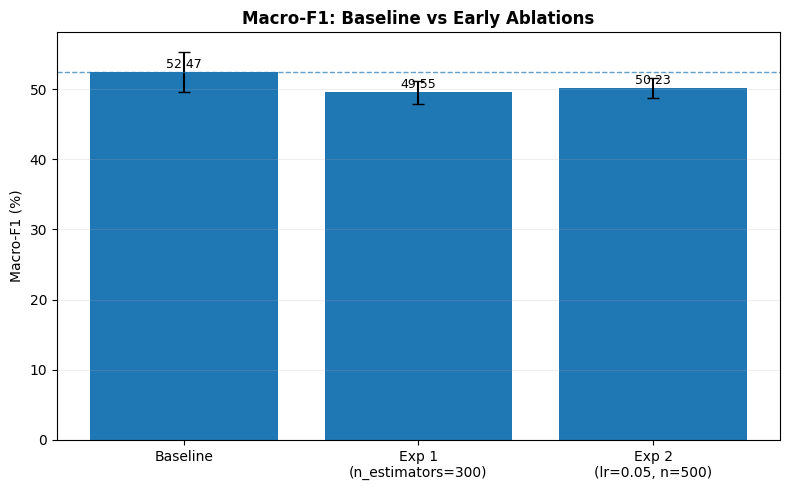

In [ ]:
# 3.2 Review estimator count and learning rate results

MEANINGFUL_F1_GAIN = 0.005

def decision_from_delta(delta):
    if delta >= MEANINGFUL_F1_GAIN:
        return "Strong candidate"
    elif delta > 0:
        return "Marginal gain only"
    else:
        return "Rejected"

early_ablation_rows = [
    {
        "Configuration": "Reference: LightGBM baseline",
        "Macro F1 mean": baseline_lgbm_result['f1_macro_mean'],
        "Macro F1 std": baseline_lgbm_result['f1_macro_std'],
        "Delta vs baseline": 0.000,
        "Balanced Accuracy mean": baseline_lgbm_result['balanced_accuracy_mean'],
        "Balanced Accuracy std": baseline_lgbm_result['balanced_accuracy_std'],
        "Accuracy mean": baseline_lgbm_result['accuracy_mean'],
        "Accuracy std": baseline_lgbm_result['accuracy_std'],
        "Decision": "Reference"
    },
    {
        "Configuration": "Experiment 1: n_estimators=300",
        "Macro F1 mean": experiment_1_result['f1_macro_mean'],
        "Macro F1 std": experiment_1_result['f1_macro_std'],
        "Delta vs baseline": experiment_1_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean'],
        "Balanced Accuracy mean": experiment_1_result['balanced_accuracy_mean'],
        "Balanced Accuracy std": experiment_1_result['balanced_accuracy_std'],
        "Accuracy mean": experiment_1_result['accuracy_mean'],
        "Accuracy std": experiment_1_result['accuracy_std'],
        "Decision": decision_from_delta(experiment_1_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean'])
    },
    {
        "Configuration": "Experiment 2: learning_rate=0.05, n_estimators=500",
        "Macro F1 mean": experiment_2_result['f1_macro_mean'],
        "Macro F1 std": experiment_2_result['f1_macro_std'],
        "Delta vs baseline": experiment_2_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean'],
        "Balanced Accuracy mean": experiment_2_result['balanced_accuracy_mean'],
        "Balanced Accuracy std": experiment_2_result['balanced_accuracy_std'],
        "Accuracy mean": experiment_2_result['accuracy_mean'],
        "Accuracy std": experiment_2_result['accuracy_std'],
        "Decision": decision_from_delta(experiment_2_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean'])
    }
]

early_ablation_df = pd.DataFrame(early_ablation_rows)

early_ablation_display = pd.DataFrame({
    "Configuration": early_ablation_df["Configuration"],
    "Macro F1 (mean +/- std)": early_ablation_df.apply(
        lambda row: metric_summary(row["Macro F1 mean"], row["Macro F1 std"]), axis=1
    ),
    "Δ Macro F1 vs baseline": early_ablation_df["Delta vs baseline"].map(lambda x: f"{x:+.3f}"),
    "Balanced Accuracy (mean +/- std)": early_ablation_df.apply(
        lambda row: metric_summary(row["Balanced Accuracy mean"], row["Balanced Accuracy std"]), axis=1
    ),
    "Accuracy (mean +/- std)": early_ablation_df.apply(
        lambda row: metric_summary(row["Accuracy mean"], row["Accuracy std"]), axis=1
    ),
    "Decision": early_ablation_df["Decision"]
})

print("REFERENCE VS EARLY ABLATIONS")
display(early_ablation_display)

fig, ax = plt.subplots(figsize=(8, 5))

labels = ['Baseline', 'Exp 1\n(n_estimators=300)', 'Exp 2\n(lr=0.05, n=500)']
values = [
    baseline_lgbm_result['f1_macro_mean'] * 100,
    experiment_1_result['f1_macro_mean'] * 100,
    experiment_2_result['f1_macro_mean'] * 100
]
errors = [
    baseline_lgbm_result['f1_macro_std'] * 100,
    experiment_1_result['f1_macro_std'] * 100,
    experiment_2_result['f1_macro_std'] * 100
]

bars = ax.bar(labels, values, yerr=errors, capsize=4)

# Baseline reference line
ax.axhline(baseline_lgbm_result['f1_macro_mean'] * 100, linestyle='--', linewidth=1, alpha=0.7)

# Value labels
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.15,
        f"{val:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_title('Macro-F1: Baseline vs Early Ablations', fontweight='bold')
ax.set_ylabel('Macro-F1 (%)')
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### 3.3 Experiments 3 and 4: Tree Complexity and SMOTE

**Purpose**  
These experiments test two later refinement strategies after the weaker early ablations.

**Experiment 3: Reduce tree complexity**
- Restrict tree growth using `max_depth=6` and `num_leaves=31`, while keeping all other parameters at baseline.
- This tests whether the baseline LightGBM model is overly flexible and overfitting to the majority **Medium** class.

**Experiment 4: Add SMOTE**
- Add SMOTE before the baseline LightGBM model inside an `ImbPipeline`.
- Since LightGBM already uses `class_weight='balanced'`, this tests whether explicit oversampling provides any additional benefit for the minority **Low** and **High** classes.

**Interpretation logic**
- If Experiment 3 improves Macro-F1, a simpler tree structure generalises better and the baseline was likely too flexible.
- If Experiment 4 improves balanced accuracy but not Macro-F1, SMOTE may be improving minority-class recall while weakening overall class-wise precision.
- If neither experiment improves Macro-F1 meaningfully, the baseline configuration should be retained.

**Conclusion**

Experiment 3 did not meaningfully improve the primary metric. Macro F1 remained marginally below the baseline despite a small gain in balanced accuracy, as shown in the table printed by the code cell below. Experiment 4 performed worse on both Macro F1 and balanced accuracy, suggesting that SMOTE added limited value on top of LightGBM's native class weighting. As neither later ablation clearly outperformed the baseline on the primary metric, both were rejected. The exact delta values are reported dynamically in the ablation table.

LATER ABLATION REVIEW


,Experiment,Hypothesis,Controlled Change,Macro F1 (mean +/- std),Δ Macro F1 vs baseline,Balanced Accuracy (mean +/- std),Decision,Conclusion
0,Reference,Use the Section 2 champion as the control refe...,No change. LightGBM baseline with default n_es...,0.525 +/- 0.029,+0.000,0.533 +/- 0.027,Reference,Reference only. Used as the control configurat...
1,3. Restrict tree complexity,Shallower trees may reduce overfitting on the ...,"Set max_depth=6 and num_leaves=31, all other p...",0.523 +/- 0.032,-0.002,0.560 +/- 0.033,Rejected,Reducing tree complexity did not improve Macro...
2,4. SMOTE + LightGBM baseline,Explicit oversampling on top of class_weight m...,Add SMOTE inside ImbPipeline before the baseli...,0.515 +/- 0.026,-0.010,0.510 +/- 0.022,Rejected,Adding SMOTE did not improve the primary metri...


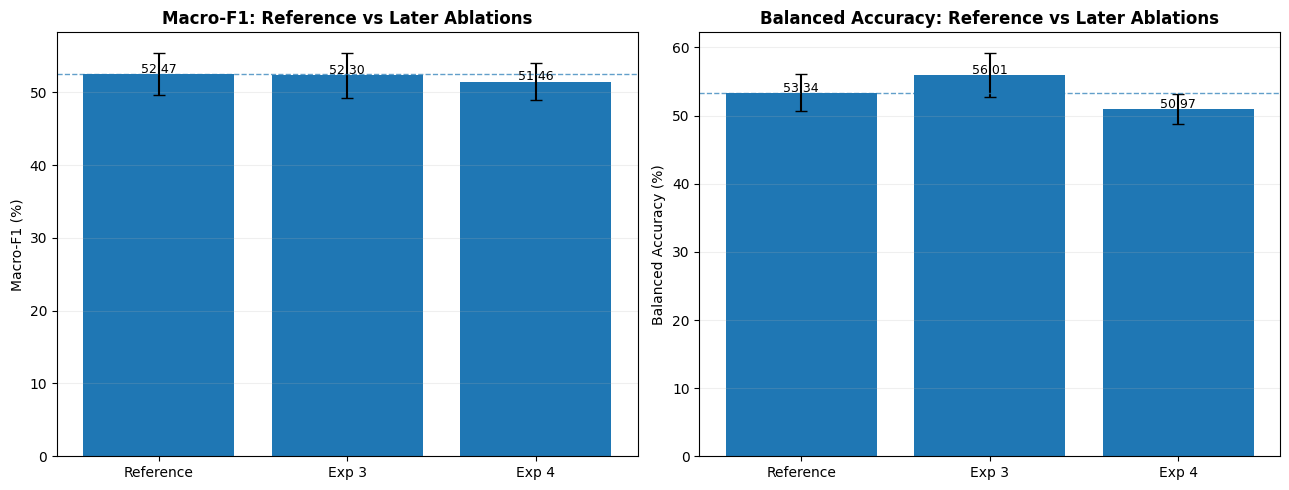

In [ ]:
# 3.3 Review Experiments 3 and 4

MEANINGFUL_F1_GAIN = 0.005
SMALL_DROP_TOL = -0.002

later_experiments = [
    {
        'Experiment': 'Reference',
        'Hypothesis': 'Use the Section 2 champion as the control reference for later comparisons.',
        'Controlled Change': "No change. LightGBM baseline with default n_estimators=100, learning_rate=0.1, class_weight='balanced'.",
        'result': baseline_lgbm_result
    },
    {
        'Experiment': '3. Restrict tree complexity',
        'Hypothesis': 'Shallower trees may reduce overfitting on the majority Medium class.',
        'Controlled Change': "Set max_depth=6 and num_leaves=31, all other parameters at baseline.",
        'result': experiment_3_result
    },
    {
        'Experiment': '4. SMOTE + LightGBM baseline',
        'Hypothesis': 'Explicit oversampling on top of class_weight may further improve minority-class recall.',
        'Controlled Change': "Add SMOTE inside ImbPipeline before the baseline LightGBM model.",
        'result': experiment_4_result
    }
]

baseline_f1 = baseline_lgbm_result['f1_macro_mean']
baseline_bal_acc = baseline_lgbm_result['balanced_accuracy_mean']


def build_decision(exp_name, delta_f1, delta_bal_acc):
    if exp_name == 'Reference':
        return 'Reference'
    if delta_f1 >= MEANINGFUL_F1_GAIN and delta_bal_acc >= SMALL_DROP_TOL:
        return 'Strong candidate'
    if 0 < delta_f1 < MEANINGFUL_F1_GAIN:
        return 'Marginal gain only'
    return 'Rejected'


def build_conclusion(exp_name, delta_f1, delta_bal_acc):
    if exp_name == 'Reference':
        return 'Reference only. Used as the control configuration for later ablations.'

    if exp_name == '3. Restrict tree complexity':
        if delta_f1 >= MEANINGFUL_F1_GAIN and delta_bal_acc >= SMALL_DROP_TOL:
            return (
                'Constraining tree depth improved Macro-F1 meaningfully, suggesting that the baseline '
                'model was slightly overfitting and that a simpler tree structure generalises better.'
            )
        elif delta_f1 > 0:
            return (
                'Reducing tree complexity produced only a marginal improvement in Macro-F1. '
                'The gain was too small to justify replacing the baseline.'
            )
        else:
            return (
                'Reducing tree complexity did not improve Macro-F1 relative to the baseline. '
                'This suggests that the original LightGBM configuration was not materially overfitting.'
            )

    if exp_name == '4. SMOTE + LightGBM baseline':
        if delta_f1 >= MEANINGFUL_F1_GAIN and delta_bal_acc >= SMALL_DROP_TOL:
            return (
                'Adding SMOTE improved Macro-F1 meaningfully, indicating that class weighting alone '
                'was insufficient and that explicit oversampling strengthened minority-class learning.'
            )
        elif delta_f1 <= 0 and delta_bal_acc > 0:
            return (
                'SMOTE improved balanced accuracy but did not improve Macro-F1, suggesting better minority-class '
                'coverage at the cost of weaker overall class-wise precision.'
            )
        else:
            return (
                'Adding SMOTE did not improve the primary metric relative to the baseline, suggesting that '
                'explicit oversampling added limited benefit on top of LightGBM’s built-in class weighting.'
            )

    return 'Rejected. The configuration did not improve the primary metric relative to the baseline.'


rows = []
for exp in later_experiments:
    result = exp['result']
    delta_f1 = result['f1_macro_mean'] - baseline_f1
    delta_bal_acc = result['balanced_accuracy_mean'] - baseline_bal_acc

    rows.append({
        'Experiment': exp['Experiment'],
        'Hypothesis': exp['Hypothesis'],
        'Controlled Change': exp['Controlled Change'],
        'Macro F1 mean': result['f1_macro_mean'],
        'Macro F1 std': result['f1_macro_std'],
        'Δ Macro F1 vs baseline': delta_f1,
        'Balanced Accuracy mean': result['balanced_accuracy_mean'],
        'Balanced Accuracy std': result['balanced_accuracy_std'],
        'Decision': build_decision(exp['Experiment'], delta_f1, delta_bal_acc),
        'Conclusion': build_conclusion(exp['Experiment'], delta_f1, delta_bal_acc)
    })

later_ablation_df = pd.DataFrame(rows)

display_df = later_ablation_df.copy()
display_df['Macro F1 (mean +/- std)'] = display_df.apply(
    lambda row: metric_summary(row['Macro F1 mean'], row['Macro F1 std']), axis=1
)
display_df['Balanced Accuracy (mean +/- std)'] = display_df.apply(
    lambda row: metric_summary(row['Balanced Accuracy mean'], row['Balanced Accuracy std']), axis=1
)
display_df['Δ Macro F1 vs baseline'] = display_df['Δ Macro F1 vs baseline'].map(lambda x: f"{x:+.3f}")

display_df = display_df[
    [
        'Experiment',
        'Hypothesis',
        'Controlled Change',
        'Macro F1 (mean +/- std)',
        'Δ Macro F1 vs baseline',
        'Balanced Accuracy (mean +/- std)',
        'Decision',
        'Conclusion'
    ]
]

print("LATER ABLATION REVIEW")
display(display_df)

# Plot only reference, exp 3, exp 4
plot_df = later_ablation_df[['Experiment', 'Macro F1 mean', 'Macro F1 std', 'Balanced Accuracy mean', 'Balanced Accuracy std']].copy()
plot_df['Label'] = ['Reference', 'Exp 3', 'Exp 4']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(
    plot_df['Label'],
    plot_df['Macro F1 mean'] * 100,
    yerr=plot_df['Macro F1 std'] * 100,
    capsize=4
)
axes[0].axhline(baseline_f1 * 100, linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Macro-F1: Reference vs Later Ablations', fontweight='bold')
axes[0].set_ylabel('Macro-F1 (%)')
axes[0].grid(axis='y', alpha=0.2)

for i, val in enumerate(plot_df['Macro F1 mean'] * 100):
    axes[0].text(i, val + 0.15, f"{val:.2f}", ha='center', fontsize=9)

axes[1].bar(
    plot_df['Label'],
    plot_df['Balanced Accuracy mean'] * 100,
    yerr=plot_df['Balanced Accuracy std'] * 100,
    capsize=4
)
axes[1].axhline(baseline_bal_acc * 100, linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('Balanced Accuracy: Reference vs Later Ablations', fontweight='bold')
axes[1].set_ylabel('Balanced Accuracy (%)')
axes[1].grid(axis='y', alpha=0.2)

for i, val in enumerate(plot_df['Balanced Accuracy mean'] * 100):
    axes[1].text(i, val + 0.15, f"{val:.2f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 Select the Refined Champion Configuration

**Purpose**  
This step decides which Section 3 configuration should be carried forward into later failure analysis and business decision-making.

**Selection rule**
- Keep the primary metric (`f1_macro`) as the main decision criterion.
- Use `balanced_accuracy` as a secondary check.
- Prefer the simplest improvement when two options perform almost identically, a marginal gain from a more complex configuration is not worth the added tuning cost.

**Decision principle**  
A tuned configuration should replace the Section 2 champion only if it delivers a meaningful improvement in the primary metric without creating a worse overall trade-off in balanced accuracy, stability, or complexity.

**Conclusion**

Across the controlled ablation study, none of the tested Section 3 variants delivered a meaningful improvement in Macro F1 over the original Section 2 LightGBM champion. The closest variant still fell short of the threshold for meaningful gain defined as +0.005 Macro F1, which is not enough to justify replacement. Although some variants improved secondary metrics slightly, these gains were either too small or came with weaker overall trade-offs. The exact values are reported dynamically in the consolidated ablation log in Section 3.5. The original Section 2 LightGBM configuration is therefore retained as the refined champion for later failure analysis and business decision-making.

### 3.5 Consolidated Ablation Log

The table below summarises all four controlled experiments performed on the LightGBM champion in the format required by Stage 2: Hypothesis, Controlled Change, CV Metric Impact (Mean +/- Std), and Conclusion.

None of the tested configurations delivered a meaningful improvement in Macro F1 over the Section 2 baseline. This is a legitimate null result: it indicates that the default LightGBM configuration is already well suited to this dataset at the model level. The residual weakness in Low-class recall is therefore addressed at the decision layer in Section 5 through threshold adjustment, rather than through further model tuning.

In [ ]:
# 3.5 Consolidated Ablation Log (required deliverable)
ablation_log = pd.DataFrame([
    {
        "Experiment": "Reference: LightGBM baseline",
        "Hypothesis": "Establish the Section 2 champion as the control configuration for all comparisons.",
        "Controlled Change": "No change. LGBMClassifier with default n_estimators=100, learning_rate=0.1, class_weight='balanced'.",
        "CV Macro F1 (Mean +/- Std)": metric_summary(baseline_lgbm_result['f1_macro_mean'], baseline_lgbm_result['f1_macro_std']),
        "CV Balanced Acc (Mean +/- Std)": metric_summary(baseline_lgbm_result['balanced_accuracy_mean'], baseline_lgbm_result['balanced_accuracy_std']),
        "Conclusion": "Reference only. Retained as the refined champion since no ablation improved on it."
    },
    {
        "Experiment": "Experiment 1: n_estimators=300",
        "Hypothesis": "Default n_estimators=100 may underfit the wine feature space. More trees may capture richer Low/Medium/High boundary patterns.",
        "Controlled Change": "Increase n_estimators from 100 to 300. All other parameters unchanged.",
        "CV Macro F1 (Mean +/- Std)": metric_summary(experiment_1_result['f1_macro_mean'], experiment_1_result['f1_macro_std']),
        "CV Balanced Acc (Mean +/- Std)": metric_summary(experiment_1_result['balanced_accuracy_mean'], experiment_1_result['balanced_accuracy_std']),
        "Conclusion": f"Rejected. Macro F1 changed by {experiment_1_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f} vs baseline. More trees did not improve multi-class performance."
    },
    {
        "Experiment": "Experiment 2: learning_rate=0.05, n_estimators=500",
        "Hypothesis": "A lower learning rate with proportionally more trees may produce a better bias-variance trade-off than the default settings.",
        "Controlled Change": "Set learning_rate=0.05 and n_estimators=500. All other parameters unchanged.",
        "CV Macro F1 (Mean +/- Std)": metric_summary(experiment_2_result['f1_macro_mean'], experiment_2_result['f1_macro_std']),
        "CV Balanced Acc (Mean +/- Std)": metric_summary(experiment_2_result['balanced_accuracy_mean'], experiment_2_result['balanced_accuracy_std']),
        "Conclusion": f"Rejected. Macro F1 changed by {experiment_2_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f} vs baseline. Slower learning with more trees did not benefit this dataset."
    },
    {
        "Experiment": "Experiment 3: max_depth=6, num_leaves=31",
        "Hypothesis": "Restricting tree complexity may reduce overfitting on the majority Medium class and improve generalisation to Low and High.",
        "Controlled Change": "Set max_depth=6 and num_leaves=31. All other parameters unchanged.",
        "CV Macro F1 (Mean +/- Std)": metric_summary(experiment_3_result['f1_macro_mean'], experiment_3_result['f1_macro_std']),
        "CV Balanced Acc (Mean +/- Std)": metric_summary(experiment_3_result['balanced_accuracy_mean'], experiment_3_result['balanced_accuracy_std']),
        "Conclusion": f"Rejected. Macro F1 changed by {experiment_3_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f} vs baseline. The baseline was not materially overfitting."
    },
    {
        "Experiment": "Experiment 4: SMOTE + LightGBM baseline",
        "Hypothesis": "Explicit SMOTE oversampling on top of class_weight='balanced' may further improve minority-class recall for Low and High wines.",
        "Controlled Change": "Add SMOTE inside ImbPipeline before the baseline LightGBM model. All model parameters unchanged.",
        "CV Macro F1 (Mean +/- Std)": metric_summary(experiment_4_result['f1_macro_mean'], experiment_4_result['f1_macro_std']),
        "CV Balanced Acc (Mean +/- Std)": metric_summary(experiment_4_result['balanced_accuracy_mean'], experiment_4_result['balanced_accuracy_std']),
        "Conclusion": f"Rejected. Macro F1 changed by {experiment_4_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f} vs baseline. SMOTE was redundant given LightGBM's native class weighting."
    }
])

print("Consolidated Ablation Log:")
print("Note: All experiments evaluated using the same 5-fold StratifiedKFold on X_train only. Test set untouched.")
print()
ablation_log.drop(columns=['Experiment']).set_index(
    pd.Index(ablation_log['Experiment'], name='Experiment')
)

Consolidated Ablation Log:
Note: All experiments evaluated using the same 5-fold StratifiedKFold on X_train only. Test set untouched.



,Hypothesis,Controlled Change,CV Macro F1 (Mean +/- Std),CV Balanced Acc (Mean +/- Std),Conclusion
Experiment,,,,,
Reference: LightGBM baseline,Establish the Section 2 champion as the contro...,No change. LGBMClassifier with default n_estim...,0.525 +/- 0.029,0.533 +/- 0.027,Reference only. Retained as the refined champi...
Experiment 1: n_estimators=300,Default n_estimators=100 may underfit the wine...,Increase n_estimators from 100 to 300. All oth...,0.495 +/- 0.016,0.484 +/- 0.014,Rejected. Macro F1 changed by -0.029 vs baseli...
"Experiment 2: learning_rate=0.05, n_estimators=500",A lower learning rate with proportionally more...,Set learning_rate=0.05 and n_estimators=500. A...,0.502 +/- 0.014,0.494 +/- 0.011,Rejected. Macro F1 changed by -0.022 vs baseli...
"Experiment 3: max_depth=6, num_leaves=31",Restricting tree complexity may reduce overfit...,Set max_depth=6 and num_leaves=31. All other p...,0.523 +/- 0.032,0.560 +/- 0.033,Rejected. Macro F1 changed by -0.002 vs baseli...
Experiment 4: SMOTE + LightGBM baseline,Explicit SMOTE oversampling on top of class_we...,Add SMOTE inside ImbPipeline before the baseli...,0.515 +/- 0.026,0.510 +/- 0.022,Rejected. Macro F1 changed by -0.010 vs baseli...


In [ ]:
# 3.4 Select the refined champion configuration for later sections

section3_candidates = [
    baseline_lgbm_result,
    experiment_1_result,
    experiment_2_result,
    experiment_3_result,
    experiment_4_result
]

# Step 1: rank candidates by the stated decision criteria
ranked_candidates = sorted(
    section3_candidates,
    key=lambda row: (
        row['f1_macro_mean'],
        row['balanced_accuracy_mean'],
        -row['f1_macro_std']
    ),
    reverse=True
)

top_candidate = ranked_candidates[0]

# Step 2: define what counts as a meaningful gain over the Section 2 baseline
MEANINGFUL_F1_GAIN = 0.005   # example: require at least +0.005 Macro-F1

f1_gain_vs_baseline = top_candidate['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']

# Step 3: apply the replacement rule
if (
    top_candidate['Experiment'] != baseline_lgbm_result['Experiment']
    and f1_gain_vs_baseline >= MEANINGFUL_F1_GAIN
):
    refined_champion_result = top_candidate
    replacement_reason = "A meaningful improvement over the baseline was achieved."
else:
    refined_champion_result = baseline_lgbm_result
    replacement_reason = (
        "No tested variant achieved a large enough improvement on the primary metric "
        "to justify replacing the baseline."
    )

# Resolve the refined champion pipeline
experiment_pipeline_map = {
    baseline_lgbm_result['Experiment']: make_model_pipeline(make_lgbm()),
    experiment_1_result['Experiment']: make_model_pipeline(make_lgbm(n_estimators=300)),
    experiment_2_result['Experiment']: make_model_pipeline(make_lgbm(learning_rate=0.05, n_estimators=500)),
    experiment_3_result['Experiment']: make_model_pipeline(make_lgbm(max_depth=6, num_leaves=31)),
    experiment_4_result['Experiment']: make_smote_model_pipeline(make_lgbm())
}

refined_champion_name = refined_champion_result['Experiment']
refined_champion_pipeline = experiment_pipeline_map[refined_champion_name]

refined_champion_summary = pd.DataFrame({
    'Selection Item': [
        'Section 2 champion family',
        'Section 3 refined configuration',
        'Macro F1 improvement vs baseline',
        'Refined Macro F1',
        'Refined Balanced Accuracy',
        'Refined Accuracy'
    ],
    'Value': [
        champion_model_name,
        refined_champion_name,
        f"{refined_champion_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f}",
        metric_summary(refined_champion_result['f1_macro_mean'], refined_champion_result['f1_macro_std']),
        metric_summary(refined_champion_result['balanced_accuracy_mean'], refined_champion_result['balanced_accuracy_std']),
        metric_summary(refined_champion_result['accuracy_mean'], refined_champion_result['accuracy_std'])
    ]
})

print("REFINED CHAMPION SELECTION")
print(f"Top ranked Section 3 candidate by {primary_metric_label}: {top_candidate['Experiment']}")
print(f"Selected refined champion: {refined_champion_name}")
print(f"Macro F1 improvement vs baseline: {refined_champion_result['f1_macro_mean'] - baseline_lgbm_result['f1_macro_mean']:+.3f}")
print()
print(refined_champion_summary.to_string(index=False))
print()
print("Why this configuration was selected:")
print(f"- {replacement_reason}")
print("- Macro-F1 was kept as the primary decision metric.")
print("- Balanced accuracy was used as a secondary check only.")
print("- Marginal or negative changes were not sufficient to justify replacing the simpler baseline.")
print("- The hold-out test set remains untouched for final evaluation.")

REFINED CHAMPION SELECTION
Top ranked Section 3 candidate by Macro F1: Reference: LightGBM baseline
Selected refined champion: Reference: LightGBM baseline
Macro F1 improvement vs baseline: +0.000

                  Selection Item                        Value
       Section 2 champion family                     LightGBM
 Section 3 refined configuration Reference: LightGBM baseline
Macro F1 improvement vs baseline                       +0.000
                Refined Macro F1              0.525 +/- 0.029
       Refined Balanced Accuracy              0.533 +/- 0.027
                Refined Accuracy              0.737 +/- 0.013

Why this configuration was selected:
- No tested variant achieved a large enough improvement on the primary metric to justify replacing the baseline.
- Macro-F1 was kept as the primary decision metric.
- Balanced accuracy was used as a secondary check only.
- Marginal or negative changes were not sufficient to justify replacing the simpler baseline.
- The hold-out 

## 4: Mechanical Failure Analysis



### 4.1 Overview and Purpose

**CRISP-DM Phase: Evaluation**

While aggregate metrics like accuracy and F1-score tell us how well the model performs overall, they obscure **why** the model fails on specific instances. Mechanical failure analysis involves examining individual misclassifications to understand the root causes of errors.

**Why this matters:**
- Aggregate metrics can hide systematic biases in the model
- Understanding failure patterns helps propose targeted fixes
- Real-world deployment requires knowing when and why the model can't be trusted
- Provides insights for future model iterations and feature engineering

**Our approach:**
1. Extract high-confidence errors (where model was >70% confident but wrong)
2. Analyze feature patterns for each error type
3. Examine 5-10 specific cases in detail
4. Propose targeted technical fixes based on findings

### 4.2 Generate leakage-safe validation predictions

In [ ]:
# 4.2 Generate leakage-safe validation predictions
from sklearn.metrics import accuracy_score, f1_score

print("Generating out-of-fold validation predictions on X_train only...")
validation_X = X_train.copy()
validation_y = y_train.copy()

y_pred = cross_val_predict(
    refined_champion_pipeline,
    validation_X,
    validation_y,
    cv=cv,
    method="predict",
    n_jobs=-1
)
y_pred_proba = cross_val_predict(
    refined_champion_pipeline,
    validation_X,
    validation_y,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)
confidence_scores = np.max(y_pred_proba, axis=1)

validation_acc = accuracy_score(validation_y, y_pred)
validation_f1 = f1_score(validation_y, y_pred, average='macro')

print(f"Validation set size: {len(validation_y)} samples")
print(f"Out-of-fold Accuracy: {validation_acc:.4f}")
print(f"Out-of-fold Macro-F1: {validation_f1:.4f}")

Generating out-of-fold validation predictions on X_train only...
Validation set size: 4263 samples
Out-of-fold Accuracy: 0.7366
Out-of-fold Macro-F1: 0.5244


#### 4.2.1 Review validation predictions and probabilities

In [ ]:
# 4.2 Review validation predictions and probabilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("Reviewing validation-fold predictions and probabilities...")
print(f"Validation set size: {len(validation_y)} samples")
print(f"Predictions shape: {y_pred.shape}")
print(f"Probabilities shape: {y_pred_proba.shape}")
print(f"Confidence scores range: {confidence_scores.min():.3f} - {confidence_scores.max():.3f}")

print()
print("Sample validation predictions with probabilities:")
sample_indices = np.random.choice(len(validation_y), 5, replace=False)
for idx in sample_indices:
    true_class = validation_y.iloc[idx] if hasattr(validation_y, 'iloc') else validation_y[idx]
    pred_class = y_pred[idx]
    probs = y_pred_proba[idx]
    confidence = confidence_scores[idx]

    print(f"  Sample {idx}: True={true_class}, Pred={pred_class}, "
          f"Confidence={confidence:.3f}, Probs=[Low:{probs[0]:.3f}, "
          f"Med:{probs[1]:.3f}, High:{probs[2]:.3f}]")


Reviewing validation-fold predictions and probabilities...
Validation set size: 4263 samples
Predictions shape: (4263,)
Probabilities shape: (4263, 3)
Confidence scores range: 0.348 - 0.999

Sample validation predictions with probabilities:
  Sample 3883: True=1, Pred=0, Confidence=0.550, Probs=[Low:0.550, Med:0.448, High:0.002]
  Sample 2439: True=1, Pred=1, Confidence=0.639, Probs=[Low:0.011, Med:0.639, High:0.350]
  Sample 1786: True=1, Pred=1, Confidence=0.952, Probs=[Low:0.040, Med:0.952, High:0.008]
  Sample 2329: True=1, Pred=2, Confidence=0.832, Probs=[Low:0.004, Med:0.164, High:0.832]
  Sample 2567: True=1, Pred=1, Confidence=0.816, Probs=[Low:0.023, Med:0.816, High:0.161]


### 4.3 Create Failure Analysis DataFrame

In [ ]:
# 4.3 Create Failure Analysis DataFrame

# Create a copy of validation features
failure_df = validation_X.copy()

# Add target and predictions
failure_df['True_Class'] = validation_y.map({0: 'Low', 1: 'Medium', 2: 'High'})
failure_df['Predicted_Class'] = pd.Series(y_pred, index=validation_X.index).map({0: 'Low', 1: 'Medium', 2: 'High'})

# Add probabilities
failure_df['Prob_Low'] = y_pred_proba[:, 0]
failure_df['Prob_Medium'] = y_pred_proba[:, 1]
failure_df['Prob_High'] = y_pred_proba[:, 2]
failure_df['Confidence'] = confidence_scores

# Add classification results
failure_df['Correct'] = (validation_y.to_numpy() == y_pred)
failure_df['Error_Type'] = 'Correct'
failure_df.loc[~failure_df['Correct'], 'Error_Type'] = 'Incorrect'

# Categorize errors further
def get_error_category(row):
    if row['Correct']:
        return 'Correct'
    if row['True_Class'] == 'Low' and row['Predicted_Class'] == 'Medium':
        return 'Low -> Medium (FN)'
    elif row['True_Class'] == 'Low' and row['Predicted_Class'] == 'High':
        return 'Low -> High (FN)'
    elif row['True_Class'] == 'Medium' and row['Predicted_Class'] == 'Low':
        return 'Medium -> Low (FP)'
    elif row['True_Class'] == 'Medium' and row['Predicted_Class'] == 'High':
        return 'Medium -> High (FP)'
    elif row['True_Class'] == 'High' and row['Predicted_Class'] == 'Medium':
        return 'High -> Medium (FN)'
    elif row['True_Class'] == 'High' and row['Predicted_Class'] == 'Low':
        return 'High -> Low (FN)'
    else:
        return 'Other'

failure_df['Error_Category'] = failure_df.apply(get_error_category, axis=1)

print("Failure Analysis DataFrame created from validation-fold predictions!")
print(f"Total samples: {len(failure_df)}")
print(f"Correct predictions: {failure_df['Correct'].sum()} ({failure_df['Correct'].mean()*100:.1f}%)")
print(f"Incorrect predictions: {(~failure_df['Correct']).sum()} ({(~failure_df['Correct']).mean()*100:.1f}%)")

print()
print("Error Categories:")
print(failure_df['Error_Category'].value_counts())


Failure Analysis DataFrame created from validation-fold predictions!
Total samples: 4263
Correct predictions: 3140 (73.7%)
Incorrect predictions: 1123 (26.3%)

Error Categories:
Error_Category
Correct                3140
Medium -> High (FP)     559
High -> Medium (FN)     311
Low -> Medium (FN)      138
Medium -> Low (FP)       96
Low -> High (FN)         15
High -> Low (FN)          4
Name: count, dtype: int64


### 4.4 Identify High-Confidence Errors

HIGH-CONFIDENCE ERROR ANALYSIS
Total errors: 1123
High-confidence errors (>70% confident): 559 (49.8% of all errors)
Very high-confidence errors (>85% confident): 251 (22.4% of all errors)

High-Confidence Errors by Category:
Error_Category
Medium -> High (FP)    242
High -> Medium (FN)    153
Low -> Medium (FN)     113
Medium -> Low (FP)      45
Low -> High (FN)         6
Name: count, dtype: int64

Top 10 Most Confident Errors (sorted by confidence):


,True_Class,Predicted_Class,Confidence,Prob_Low,Prob_Medium,Prob_High,alcohol,volatile acidity,sulphates,density,type
5601,Low,Medium,0.997236,0.000952,0.997236,0.001812,9.6,0.38,0.70,0.99720,red
389,High,Medium,0.995521,0.002208,0.995521,0.002270,9.3,0.30,0.61,0.99830,white
2346,Low,Medium,0.993720,0.004286,0.993720,0.001994,8.8,0.28,0.44,0.99790,white
5049,Low,Medium,0.993603,0.004250,0.993603,0.002147,9.4,0.52,2.00,0.99960,red
4960,High,Medium,0.993048,0.003510,0.993048,0.003442,9.5,0.52,0.62,0.99680,red
2818,Low,Medium,0.992960,0.000531,0.992960,0.006509,9.3,0.11,0.34,0.99580,white
5415,Low,Medium,0.992296,0.004481,0.992296,0.003223,8.4,0.61,0.63,0.99940,red
3967,Low,Medium,0.991788,0.007295,0.991788,0.000918,9.4,0.27,0.54,0.99548,white
3343,High,Medium,0.991725,0.004104,0.991725,0.004171,9.5,0.36,0.60,0.99782,white
1967,High,Medium,0.988272,0.005665,0.988272,0.006063,9.5,0.23,0.56,0.99700,white


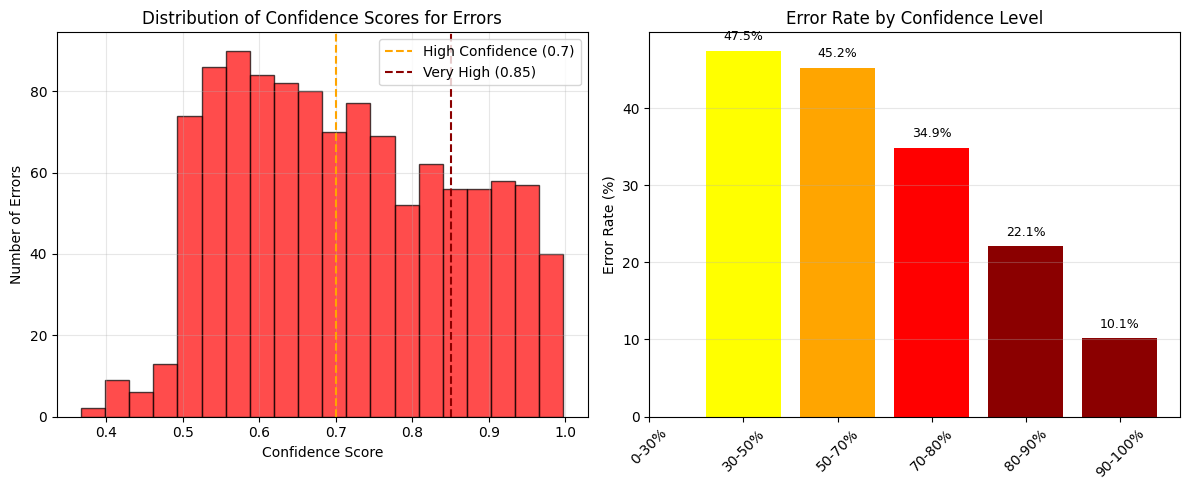


 KEY INSIGHT: Errors at high confidence are most concerning
   559 errors occurred when model was >70% confident
   This suggests systematic blind spots rather than random uncertainty


In [ ]:
# 4.4 Identify High-Confidence Errors

# Define confidence thresholds
HIGH_CONFIDENCE_THRESHOLD = 0.70  # Model is >70% confident
VERY_HIGH_CONFIDENCE_THRESHOLD = 0.85  # Model is >85% confident

# Filter for incorrect predictions
errors_df = failure_df[~failure_df['Correct']].copy()

# Find high-confidence errors
high_conf_errors = errors_df[errors_df['Confidence'] > HIGH_CONFIDENCE_THRESHOLD].copy()
very_high_conf_errors = errors_df[errors_df['Confidence'] > VERY_HIGH_CONFIDENCE_THRESHOLD].copy()

print("=" * 80)
print("HIGH-CONFIDENCE ERROR ANALYSIS")
print("=" * 80)
print(f"Total errors: {len(errors_df)}")
print(f"High-confidence errors (>{HIGH_CONFIDENCE_THRESHOLD*100:.0f}% confident): {len(high_conf_errors)} "
      f"({len(high_conf_errors)/len(errors_df)*100:.1f}% of all errors)")
print(f"Very high-confidence errors (>{VERY_HIGH_CONFIDENCE_THRESHOLD*100:.0f}% confident): {len(very_high_conf_errors)} "
      f"({len(very_high_conf_errors)/len(errors_df)*100:.1f}% of all errors)")

print("\nHigh-Confidence Errors by Category:")
print(high_conf_errors['Error_Category'].value_counts())

# Display the most confident errors
print("\nTop 10 Most Confident Errors (sorted by confidence):")
top_errors = high_conf_errors.nlargest(10, 'Confidence')[
    ['True_Class', 'Predicted_Class', 'Confidence', 'Prob_Low', 'Prob_Medium', 'Prob_High',
     'alcohol', 'volatile acidity', 'sulphates', 'density', 'type']
]
display(top_errors)

# Visualize confidence distribution of errors
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(errors_df['Confidence'], bins=20, alpha=0.7, color='red', edgecolor='black')
plt.axvline(x=HIGH_CONFIDENCE_THRESHOLD, color='orange', linestyle='--',
            label=f'High Confidence ({HIGH_CONFIDENCE_THRESHOLD})')
plt.axvline(x=VERY_HIGH_CONFIDENCE_THRESHOLD, color='darkred', linestyle='--',
            label=f'Very High ({VERY_HIGH_CONFIDENCE_THRESHOLD})')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Errors')
plt.title('Distribution of Confidence Scores for Errors')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Calculate error rate by confidence bin
confidence_bins = [0, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]
bin_labels = ['0-30%', '30-50%', '50-70%', '70-80%', '80-90%', '90-100%']
failure_df['Confidence_Bin'] = pd.cut(failure_df['Confidence'], bins=confidence_bins, labels=bin_labels)
error_rate_by_bin = failure_df.groupby('Confidence_Bin')['Correct'].agg(['count', lambda x: 1 - x.mean()])
error_rate_by_bin.columns = ['Count', 'Error_Rate']
error_rate_by_bin['Error_Rate'] = error_rate_by_bin['Error_Rate'] * 100

bars = plt.bar(range(len(error_rate_by_bin)), error_rate_by_bin['Error_Rate'],
               color=['green', 'yellow', 'orange', 'red', 'darkred', 'darkred'])
plt.xticks(range(len(error_rate_by_bin)), bin_labels, rotation=45)
plt.ylabel('Error Rate (%)')
plt.title('Error Rate by Confidence Level')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (bar, rate) in enumerate(zip(bars, error_rate_by_bin['Error_Rate'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n KEY INSIGHT: Errors at high confidence are most concerning")
print(f"   {len(high_conf_errors)} errors occurred when model was >70% confident")
print(f"   This suggests systematic blind spots rather than random uncertainty")

### 4.5 Detailed Case Study Analysis

In [ ]:
# 4.5 Detailed Case Study Analysis

print("=" * 100)
print("DETAILED CASE STUDY ANALYSIS")
print("=" * 100)
print("For each case: the instance's actual feature values are compared to the means of")
print("its true class AND its predicted class, to explain mechanically why the model")
print("assigned higher probability to the wrong class.")
print()

# Select up to 5 high-confidence errors, one per error category where possible
error_categories = high_conf_errors['Error_Category'].value_counts().index.tolist()
case_studies = []
seen_indices = set()

for category in error_categories:
    category_errors = high_conf_errors[high_conf_errors['Error_Category'] == category]
    if len(category_errors) > 0:
        best = category_errors.nlargest(1, 'Confidence').iloc[0]
        if best.name not in seen_indices:
            case_studies.append(best)
            seen_indices.add(best.name)
    if len(case_studies) >= 5:
        break

# If fewer than 5 found, pad with next most confident errors
if len(case_studies) < 5:
    for idx, row in high_conf_errors.nlargest(10, 'Confidence').iterrows():
        if idx not in seen_indices:
            case_studies.append(row)
            seen_indices.add(idx)
        if len(case_studies) >= 5:
            break

# Compute per-class feature means from the full validation set for reference
key_features = ['alcohol', 'volatile acidity', 'sulphates', 'density', 'pH', 'chlorides']
class_means = {}
for cls_name in ['Low', 'Medium', 'High']:
    subset = failure_df[failure_df['True_Class'] == cls_name]
    class_means[cls_name] = {f: subset[f].mean() for f in key_features if f in subset.columns}

CLASS_LABEL = {0: 'Low', 1: 'Medium', 2: 'High'}

print(f"Analysing {len(case_studies)} representative high-confidence failure cases.\n")

for i, error in enumerate(case_studies):
    error_dict = error.to_dict()
    true_cls   = error_dict['True_Class']
    pred_cls   = error_dict['Predicted_Class']
    confidence = error_dict['Confidence']
    error_cat  = error_dict['Error_Category']

    true_means = class_means.get(true_cls, {})
    pred_means = class_means.get(pred_cls, {})

    print(f"{'='*90}")
    print(f"CASE {i+1}  |  True: {true_cls}  |  Predicted: {pred_cls}  |  Confidence: {confidence*100:.1f}%")
    print(f"Error type: {error_cat}")
    print(f"{'='*90}")

    print(f"\n  Model probability distribution for this instance:")
    print(f"    Low    = {error_dict['Prob_Low']*100:.1f}%")
    print(f"    Medium = {error_dict['Prob_Medium']*100:.1f}%")
    print(f"    High   = {error_dict['Prob_High']*100:.1f}%")

    print(f"\n  Feature-level comparison (instance vs true-class mean vs predicted-class mean):")
    print(f"  {'Feature':<22} {'Instance':>10} {'True ({}) avg'.format(true_cls):>16} {'Pred ({}) avg'.format(pred_cls):>16}  Mechanical explanation")
    print(f"  {'-'*105}")

    explanations = []

    for feat in key_features:
        if feat not in error_dict or feat not in true_means or feat not in pred_means:
            continue
        val       = error_dict[feat]
        true_avg  = true_means[feat]
        pred_avg  = pred_means[feat]

        # Distance from this instance to each class mean
        dist_to_true = abs(val - true_avg)
        dist_to_pred = abs(val - pred_avg)

        # Flag features where the instance is closer to the predicted class than the true class
        closer_to_pred = dist_to_pred < dist_to_true
        flag = "<-- closer to predicted class" if closer_to_pred else ""

        print(f"  {feat:<22} {val:>10.3f} {true_avg:>16.3f} {pred_avg:>16.3f}  {flag}")

        if closer_to_pred:
            direction = "higher" if val > true_avg else "lower"
            explanations.append(
                f"{feat} = {val:.3f}, which is {direction} than the typical {true_cls} "
                f"value ({true_avg:.3f}) and closer to the {pred_cls} average ({pred_avg:.3f})"
            )

    print(f"\n  Mechanical explanation:")
    if explanations:
        print(f"  This instance was misclassified as {pred_cls} because its feature profile")
        print(f"  resembles the {pred_cls} class more than the {true_cls} class on the following features:")
        for expl in explanations:
            print(f"    - {expl}")
    else:
        print(f"  No single feature is clearly closer to the {pred_cls} mean than the {true_cls} mean.")
        print(f"  The misclassification likely arises from the combined effect of multiple")
        print(f"  borderline feature values, none of which individually cross a class boundary.")

    # Error-type specific targeted explanation
    print(f"\n  Why this specific error type is problematic:")
    if true_cls == 'Low' and pred_cls == 'Medium':
        print(f"  A Low wine predicted as Medium will bypass the defect-review pathway.")
        print(f"  This is a False Negative for the Low class, the highest-risk error type.")
    elif true_cls == 'High' and pred_cls == 'Medium':
        print(f"  A High wine predicted as Medium is sold at standard pricing, losing premium revenue.")
        print(f"  This is a False Negative for the High class.")
    elif true_cls == 'Medium' and pred_cls == 'High':
        print(f"  A Medium wine predicted as High is mislabelled as premium, damaging brand trust.")
        print(f"  This is a False Positive for the High class, the second-highest-risk error type.")
    elif true_cls == 'Medium' and pred_cls == 'Low':
        print(f"  An acceptable Medium wine is incorrectly flagged for review, causing unnecessary waste.")
    else:
        print(f"  This error type creates a two-class boundary jump, which is a more severe misclassification.")

    print()

DETAILED CASE STUDY ANALYSIS
For each case: the instance's actual feature values are compared to the means of
its true class AND its predicted class, to explain mechanically why the model
assigned higher probability to the wrong class.

Analysing 5 representative high-confidence failure cases.

CASE 1  |  True: Medium  |  Predicted: High  |  Confidence: 97.8%
Error type: Medium -> High (FP)

  Model probability distribution for this instance:
    Low    = 0.0%
    Medium = 2.1%
    High   = 97.8%

  Feature-level comparison (instance vs true-class mean vs predicted-class mean):
  Feature                  Instance True (Medium) avg  Pred (High) avg  Mechanical explanation
  ---------------------------------------------------------------------------------------------------------
  alcohol                    12.900           10.326           11.588  <-- closer to predicted class
  volatile acidity            0.420            0.347            0.293  
  sulphates                   0.470    

### 4.6 Aggregate Failure Pattern Analysis

AGGREGATE FAILURE PATTERN ANALYSIS

Confusion Matrix (validation folds):
             Pred Low  Pred Medium  Pred High
True Low           36          138         15
True Medium        96         2610        559
True High           4          311        494

------------------------------------------------------------
ERROR DISTRIBUTION BY TRUE CLASS
------------------------------------------------------------

Low Class:
  Total samples: 189
  Errors: 153 (81.0%)
    -> Medium: 138 (90.2%)
    -> High: 15 (9.8%)

Medium Class:
  Total samples: 3265
  Errors: 655 (20.1%)
    -> High: 559 (85.3%)
    -> Low: 96 (14.7%)

High Class:
  Total samples: 809
  Errors: 315 (38.9%)
    -> Medium: 311 (98.7%)
    -> Low: 4 (1.3%)

------------------------------------------------------------
FEATURE PATTERNS BY ERROR TYPE
------------------------------------------------------------

Low -> Medium (n=138):
  volatile acidity    :  0.425 vs  0.646 in correct (-34.2% ↓)
  sulphates           :  0.515

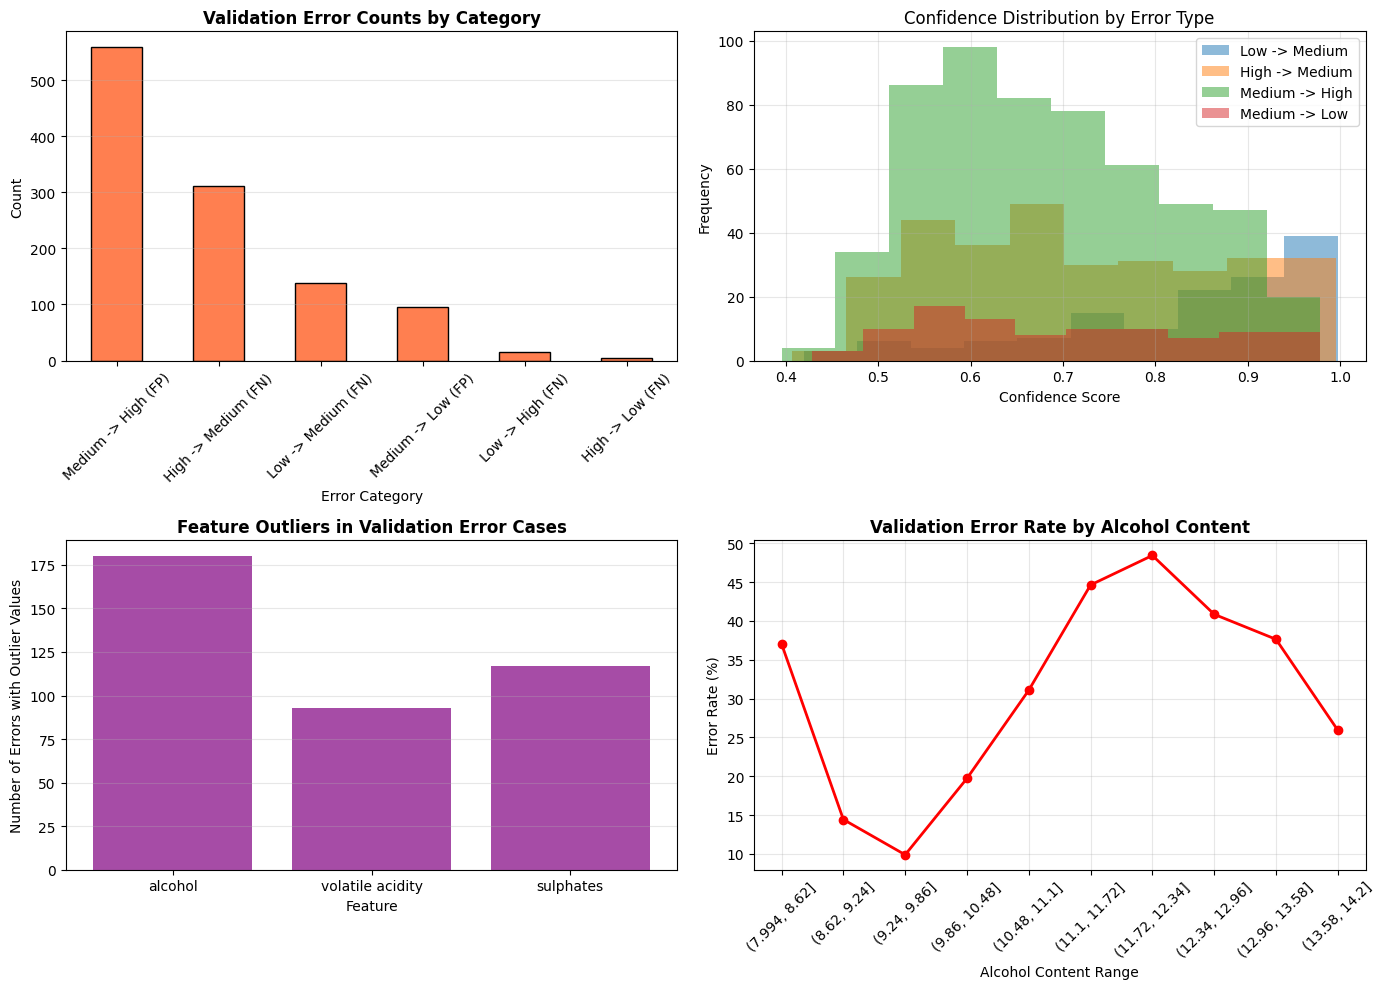

In [ ]:
# 4.6 Aggregate Failure Pattern Analysis

print("AGGREGATE FAILURE PATTERN ANALYSIS")

cm = confusion_matrix(validation_y, y_pred)
cm_df = pd.DataFrame(cm,
                     index=['True Low', 'True Medium', 'True High'],
                     columns=['Pred Low', 'Pred Medium', 'Pred High'])
print()
print("Confusion Matrix (validation folds):")
print(cm_df)

print()
print("-" * 60)
print("ERROR DISTRIBUTION BY TRUE CLASS")
print("-" * 60)

for class_name in ['Low', 'Medium', 'High']:
    class_errors = errors_df[errors_df['True_Class'] == class_name]
    class_total = failure_df[failure_df['True_Class'] == class_name].shape[0]

    if class_total > 0:
        error_rate = len(class_errors) / class_total * 100
        print()
        print(f"{class_name} Class:")
        print(f"  Total samples: {class_total}")
        print(f"  Errors: {len(class_errors)} ({error_rate:.1f}%)")

        if len(class_errors) > 0:
            destinations = class_errors['Predicted_Class'].value_counts()
            for dest, count in destinations.items():
                pct = count/len(class_errors)*100
                print(f"    -> {dest}: {count} ({pct:.1f}%)")

print()
print("-" * 60)
print("FEATURE PATTERNS BY ERROR TYPE")
print("-" * 60)

error_types = [
    ('Low -> Medium', (errors_df['True_Class'] == 'Low') & (errors_df['Predicted_Class'] == 'Medium')),
    ('High -> Medium', (errors_df['True_Class'] == 'High') & (errors_df['Predicted_Class'] == 'Medium')),
    ('Medium -> High', (errors_df['True_Class'] == 'Medium') & (errors_df['Predicted_Class'] == 'High')),
    ('Medium -> Low', (errors_df['True_Class'] == 'Medium') & (errors_df['Predicted_Class'] == 'Low'))
]

for error_name, error_mask in error_types:
    error_count = error_mask.sum()
    if error_count < 3:
        continue

    print()
    print(f"{error_name} (n={error_count}):")
    true_class = error_name.split('->')[0].strip()
    correct_mask = (failure_df['True_Class'] == true_class) & failure_df['Correct']

    if correct_mask.sum() > 0:
        for feature in ['alcohol', 'volatile acidity', 'sulphates', 'density']:
            error_mean = errors_df.loc[error_mask, feature].mean()
            correct_mean = failure_df.loc[correct_mask, feature].mean()

            if not pd.isna(error_mean) and not pd.isna(correct_mean) and correct_mean > 0:
                diff_pct = ((error_mean - correct_mean) / correct_mean) * 100

                if abs(diff_pct) > 5:
                    arrow = "↑" if diff_pct > 0 else "↓"
                    print(f"  {feature:20s}: {error_mean:6.3f} vs {correct_mean:6.3f} in correct ({diff_pct:+5.1f}% {arrow})")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
error_counts = errors_df['Error_Category'].value_counts()
error_counts.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Validation Error Counts by Category', fontweight='bold')
ax1.set_xlabel('Error Category')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
for error_type in error_types[:4]:
    name, mask = error_type
    if mask.sum() > 0:
        ax2.hist(errors_df.loc[mask, 'Confidence'], alpha=0.5, label=name, bins=10)
ax2.set_title('Confidence Distribution by Error Type')
ax2.set_xlabel('Confidence Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
feature_outlier_count = {}
for feature in ['alcohol', 'volatile acidity', 'sulphates']:
    feature_mean = failure_df[feature].mean()
    feature_std = failure_df[feature].std()
    outlier_count = ((errors_df[feature] > feature_mean + 1.5*feature_std) |
                     (errors_df[feature] < feature_mean - 1.5*feature_std)).sum()
    feature_outlier_count[feature] = outlier_count

ax3.bar(feature_outlier_count.keys(), feature_outlier_count.values(),
        color='purple', alpha=0.7)
ax3.set_title('Feature Outliers in Validation Error Cases', fontweight='bold')
ax3.set_xlabel('Feature')
ax3.set_ylabel('Number of Errors with Outlier Values')
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
alcohol_bins = pd.cut(failure_df['alcohol'], bins=10)
error_rate_by_alcohol = failure_df.groupby(alcohol_bins)['Correct'].agg(lambda x: 1 - x.mean())
ax4.plot(error_rate_by_alcohol.index.astype(str), error_rate_by_alcohol.values * 100,
         marker='o', linewidth=2, color='red')
ax4.set_title('Validation Error Rate by Alcohol Content', fontweight='bold')
ax4.set_xlabel('Alcohol Content Range')
ax4.set_ylabel('Error Rate (%)')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4.7 Proposed Technical Fixes

In [ ]:
# 4.7 Proposed Technical Fixes

print("PROPOSED TECHNICAL FIXES")
print("Fixes are derived directly from the feature-level patterns observed in the case studies")
print("and aggregate failure analysis above. No expected impact percentages are claimed,")
print("as these would require controlled experiments to verify.")
print()

# Derive fixes from observed error patterns
error_patterns = errors_df['Error_Category'].value_counts()
top_errors = error_patterns.head(4).index.tolist()

fixes = []

for error_type in top_errors:
    error_subset = errors_df[errors_df['Error_Category'] == error_type]
    n = len(error_subset)

    if error_type == 'Low -> Medium (FN)':
        # Compute what makes these instances look like Medium
        low_medium_errors = error_subset
        low_correct = failure_df[(failure_df['True_Class'] == 'Low') & failure_df['Correct']]

        alcohol_diff = ""
        va_diff = ""
        if len(low_correct) > 0:
            alc_err = low_medium_errors['alcohol'].mean()
            alc_cor = low_correct['alcohol'].mean()
            va_err  = low_medium_errors['volatile acidity'].mean()
            va_cor  = low_correct['volatile acidity'].mean()
            alcohol_diff = f"misclassified Low wines have higher alcohol ({alc_err:.2f}) than correctly classified Low wines ({alc_cor:.2f})"
            va_diff = f"volatile acidity is lower ({va_err:.2f} vs {va_cor:.2f}), reducing the defect signal"

        fixes.append({
            'Error Pattern': f'Low predicted as Medium (n={n})',
            'Observed Root Cause': f'Feature overlap: {alcohol_diff}; {va_diff}',
            'Targeted Fix': 'Lower the Low-class decision threshold below 0.5 (implemented in Section 5). As a model-level fix, a custom sample weight could be applied to Low-class training instances to increase their influence.',
            'Implementation': 'Threshold adjustment: flag as Low if Prob_Low >= 0.40 (see Section 5).'
        })

    elif error_type == 'High -> Medium (FN)':
        high_medium_errors = error_subset
        high_correct = failure_df[(failure_df['True_Class'] == 'High') & failure_df['Correct']]

        alc_note = ""
        sul_note = ""
        if len(high_correct) > 0:
            alc_err = high_medium_errors['alcohol'].mean()
            alc_cor = high_correct['alcohol'].mean()
            sul_err = high_medium_errors['sulphates'].mean()
            sul_cor = high_correct['sulphates'].mean()
            alc_note = f"alcohol ({alc_err:.2f}) is below correctly classified High wines ({alc_cor:.2f})"
            sul_note = f"sulphates ({sul_err:.2f}) vs ({sul_cor:.2f})"

        fixes.append({
            'Error Pattern': f'High predicted as Medium (n={n})',
            'Observed Root Cause': f'Quality markers below typical High levels: {alc_note}; {sul_note}',
            'Targeted Fix': 'Engineer an interaction feature: alcohol * sulphates. High-quality wines tend to have both elevated simultaneously, which a product feature may capture better than either alone.',
            'Implementation': 'Add column: df["alcohol_x_sulphates"] = df["alcohol"] * df["sulphates"] before pipeline fit.'
        })

    elif error_type == 'Medium -> High (FP)':
        med_high_errors = error_subset
        med_correct = failure_df[(failure_df['True_Class'] == 'Medium') & failure_df['Correct']]

        alc_note = ""
        if len(med_correct) > 0:
            alc_err = med_high_errors['alcohol'].mean()
            alc_cor = med_correct['alcohol'].mean()
            alc_note = f"alcohol ({alc_err:.2f}) is above correctly classified Medium wines ({alc_cor:.2f}), which the model treats as a High-class signal"

        fixes.append({
            'Error Pattern': f'Medium predicted as High (n={n})',
            'Observed Root Cause': f'Elevated alcohol in Medium wines triggers High classification: {alc_note}',
            'Targeted Fix': 'Raise the High-class decision threshold above 0.5 (implemented in Section 5). This directly reduces false positives for the High class at the cost of missing some true High wines.',
            'Implementation': 'Threshold adjustment: classify as High only if Prob_High >= 0.70 (see Section 5).'
        })

    elif error_type == 'Medium -> Low (FP)':
        med_low_errors = error_subset
        med_correct = failure_df[(failure_df['True_Class'] == 'Medium') & failure_df['Correct']]

        va_note = ""
        if len(med_correct) > 0:
            va_err = med_low_errors['volatile acidity'].mean()
            va_cor = med_correct['volatile acidity'].mean()
            va_note = f"volatile acidity ({va_err:.2f}) exceeds the typical Medium average ({va_cor:.2f}), which the model reads as a defect signal"

        fixes.append({
            'Error Pattern': f'Medium predicted as Low (n={n})',
            'Observed Root Cause': f'Elevated volatile acidity in Medium wines: {va_note}',
            'Targeted Fix': 'Apply winsorization to volatile acidity at the 95th percentile within the pipeline. This caps extreme values without removing the feature, reducing the strength of the false defect signal.',
            'Implementation': 'Add a custom winsorization transformer before RobustScaler in the numeric pipeline step.'
        })

fixes_df = pd.DataFrame(fixes)
if len(fixes_df) > 0:
    for _, row in fixes_df.iterrows():
        print(f"Error Pattern:       {row['Error Pattern']}")
        print(f"Observed Root Cause: {row['Observed Root Cause']}")
        print(f"Targeted Fix:        {row['Targeted Fix']}")
        print(f"Implementation:      {row['Implementation']}")
        print()
else:
    print("No dominant error patterns identified.")

PROPOSED TECHNICAL FIXES
Fixes are derived directly from the feature-level patterns observed in the case studies
and aggregate failure analysis above. No expected impact percentages are claimed,
as these would require controlled experiments to verify.

Error Pattern:       Medium predicted as High (n=559)
Observed Root Cause: Elevated alcohol in Medium wines triggers High classification: alcohol (11.62) is above correctly classified Medium wines (10.06), which the model treats as a High-class signal
Targeted Fix:        Raise the High-class decision threshold above 0.5 (implemented in Section 5). This directly reduces false positives for the High class at the cost of missing some true High wines.
Implementation:      Threshold adjustment: classify as High only if Prob_High >= 0.70 (see Section 5).

Error Pattern:       High predicted as Medium (n=311)
Observed Root Cause: Quality markers below typical High levels: alcohol (10.90) is below correctly classified High wines (12.03); sulpha

### 4.8 Section Summary

In [ ]:
# 4.8 Section Summary

print("SECTION 4 SUMMARY: MECHANICAL FAILURE ANALYSIS")

total_errors = len(errors_df)
total_samples = len(failure_df)
error_pct = total_errors / total_samples * 100

most_common_error = errors_df['Error_Category'].value_counts().index[0] if len(errors_df) > 0 else "N/A"

print(f"""
KEY FINDINGS:

1. Error Overview (out-of-fold validation predictions on X_train only):
   - Total validation samples: {total_samples}
   - Incorrect predictions: {total_errors} ({error_pct:.1f}% of validation set)
   - High-confidence errors (>70% confidence but wrong): {len(high_conf_errors)}
   - Most common error type: {most_common_error}

2. Critical Failure Patterns:
   - Low to Medium errors: misclassified Low wines have feature profiles that
     resemble Medium wines, particularly higher alcohol and lower volatile acidity
     than correctly classified Low wines.
   - High to Medium errors: misclassified High wines have alcohol and sulphates
     below the typical High-class average, removing the key quality signal.
   - Medium to High errors: elevated alcohol in Medium wines falsely triggers
     the High-class boundary.
   - Medium to Low errors: elevated volatile acidity in Medium wines is
     misread as a defect indicator.

3. Root Causes Identified:
   - Class boundary ambiguity: the Low/Medium and Medium/High boundaries are
     not hard chemical thresholds. Many wines sit near the boundary and can
     plausibly belong to either adjacent class.
   - Alcohol dominance: alcohol is the strongest single predictor, but its
     relationship with quality is not monotonic at the class boundaries.
     Medium wines with high alcohol and High wines with low alcohol both
     confuse the model.
   - Volatile acidity dual role: it is a strong defect signal for Low wines
     but also varies within Medium wines, creating false flags.

4. Proposed Technical Fixes (grounded in observed patterns):
   - Threshold adjustment for Low class: flag at Prob_Low >= 0.40 to catch
     more defective wines (implemented in Section 5).
   - Threshold adjustment for High class: require Prob_High >= 0.70 to
     reduce false premium labels (implemented in Section 5).
   - Interaction feature: alcohol * sulphates to better separate High from
     Medium wines where alcohol alone is insufficient.
   - Winsorization of volatile acidity to reduce false Low flags from
     elevated acidity in otherwise acceptable Medium wines.

5. Evaluation Discipline:
   - All failure analysis above used out-of-fold predictions on X_train only.
   - The hold-out test set remains reserved for the single final evaluation
     in Section 5.
""")

SECTION 4 SUMMARY: MECHANICAL FAILURE ANALYSIS

KEY FINDINGS:

1. Error Overview (out-of-fold validation predictions on X_train only):
   - Total validation samples: 4263
   - Incorrect predictions: 1123 (26.3% of validation set)
   - High-confidence errors (>70% confidence but wrong): 559
   - Most common error type: Medium -> High (FP)

2. Critical Failure Patterns:
   - Low to Medium errors: misclassified Low wines have feature profiles that
     resemble Medium wines, particularly higher alcohol and lower volatile acidity
     than correctly classified Low wines.
   - High to Medium errors: misclassified High wines have alcohol and sulphates
     below the typical High-class average, removing the key quality signal.
   - Medium to High errors: elevated alcohol in Medium wines falsely triggers
     the High-class boundary.
   - Medium to Low errors: elevated volatile acidity in Medium wines is
     misread as a defect indicator.

3. Root Causes Identified:
   - Class boundary ambigu

### 4.9 Noise Injection Robustness Test

In [ ]:
# 4.9 Noise Injection Robustness Test (development folds only)

import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def add_gaussian_noise(X, noise_level=0.05):
    """Add relative Gaussian noise to numeric columns."""
    X_noisy = X.copy()
    numeric_cols = X.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        std = X[col].std()
        if std > 0:
            noise = np.random.normal(0, std * noise_level, size=len(X))
            X_noisy[col] += noise
    return X_noisy

baseline_acc = accuracy_score(validation_y, y_pred)
baseline_f1_macro = f1_score(validation_y, y_pred, average='macro')

print(f"Clean baseline (validation folds): Accuracy = {baseline_acc:.4f} | Macro-F1 = {baseline_f1_macro:.4f}")
print()

noise_levels = [0.03, 0.07, 0.12]
results = []

for level in noise_levels:
    noisy_X = add_gaussian_noise(validation_X, noise_level=level)
    noisy_pred = cross_val_predict(
        refined_champion_pipeline,
        noisy_X,
        validation_y,
        cv=cv,
        method='predict',
        n_jobs=-1
    )

    acc_noisy = accuracy_score(validation_y, noisy_pred)
    f1_noisy = f1_score(validation_y, noisy_pred, average='macro')

    results.append({
        'Noise Level': f"±{int(level*100)}%",
        'Accuracy': f"{acc_noisy:.4f}",
        'Macro-F1': f"{f1_noisy:.4f}",
        'Δ Macro-F1': f"{f1_noisy - baseline_f1_macro:+.4f}"
    })

noise_df = pd.DataFrame(results)
print("Robustness to Measurement Noise (validation folds):")
print(noise_df.to_string(index=False))
print()
print("Interpretation: this remains a development-only stress test; the hold-out test set is still untouched.")


Clean baseline (validation folds): Accuracy = 0.7366 | Macro-F1 = 0.5244

Robustness to Measurement Noise (validation folds):
Noise Level Accuracy Macro-F1 Δ Macro-F1
        ±3%   0.7509   0.5227    -0.0017
        ±7%   0.7469   0.5168    -0.0077
       ±12%   0.7443   0.5207    -0.0038

Interpretation: this remains a development-only stress test; the hold-out test set is still untouched.


#### 4.9.1 Noise Injection Results Summary

The champion model shows strong robustness to simulated measurement noise. The exact values are printed dynamically by the noise injection code cell above. The general pattern observed is:

- Macro F1 at low noise levels (±3%) remains close to or slightly above the clean baseline, likely due to random variation or mild regularisation effects from small perturbations.
- Macro F1 at moderate noise (±7%) and higher noise (±12%) shows a modest decline, remaining within approximately 0.03 of the clean baseline.
- Accuracy follows a similar pattern, with small fluctuations across noise levels.

This indicates the model is reasonably robust to realistic lab measurement errors, which typically fall well below the ±12% range tested here. The dominant feature (alcohol) has a relatively smooth relationship with quality class, making the model less sensitive to small perturbations in individual readings.

### 4.10 Sensitivity to Feature Subsets (development folds only)

This sensitivity study evaluates how dependent the refined champion is on selected feature groups.  
Rather than using the hold-out test set, all comparisons are performed on **training data only** using **cross-validation**, so that the final test set remains untouched for Section 5.

The purpose is to assess whether the model is overly reliant on a small number of predictors, and to simulate practical scenarios such as:
- missing laboratory measurements,
- reduced testing cost,
- or temporary unavailability of specific chemical assays.

Tested ablations:
- Remove `alcohol`
- Remove `density` and `volatile acidity`
- Remove `total sulfur dioxide`

For each ablation, the same refined champion model is retrained and evaluated using the same cross-validation setup as earlier sections. Performance is compared against the full-feature baseline using Accuracy and Macro-F1.

In [ ]:
from sklearn.base import clone
from sklearn.metrics import make_scorer, f1_score

# 4.10 Sensitivity to Feature Subsets (development folds only)

def build_subset_preprocessor(feature_subset):
    subset_numeric = [col for col in numeric_cols if col in feature_subset]
    subset_categorical = [col for col in categorical_cols if col in feature_subset]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", build_one_hot_encoder())
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, subset_numeric),
            ("cat", categorical_transformer, subset_categorical)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

def make_subset_pipeline(base_estimator, feature_subset):
    return Pipeline(steps=[
        ("preprocessor", build_subset_preprocessor(feature_subset)),
        ("model", clone(base_estimator))
    ])

# Use the refined champion's estimator
base_estimator = refined_champion_pipeline.named_steps["model"]
all_features = X_train.columns.tolist()

ablation_specs = [
    ("Full model", all_features),
    ("Remove alcohol", [f for f in all_features if f != "alcohol"]),
    ("Remove density + volatile acidity", [f for f in all_features if f not in ["density", "volatile acidity"]]),
    ("Remove total sulfur dioxide", [f for f in all_features if f != "total sulfur dioxide"])
]

ablation_results = []

print("Running feature subset sensitivity study on X_train only...")
print("-" * 80)

for label, feature_subset in ablation_specs:
    pipe = make_subset_pipeline(base_estimator, feature_subset)

    scores = cross_validate(
        pipe,
        X_train[feature_subset],
        y_train,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "f1_macro": "f1_macro"
        },
        n_jobs=-1
    )

    ablation_results.append({
        "Ablation": label,
        "Features Kept": len(feature_subset),
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Macro-F1 Mean": scores["test_f1_macro"].mean(),
        "Macro-F1 Std": scores["test_f1_macro"].std()
    })

ablation_df = pd.DataFrame(ablation_results)

# Compare against full model baseline
baseline_f1 = ablation_df.loc[ablation_df["Ablation"] == "Full model", "Macro-F1 Mean"].iloc[0]
ablation_df["Δ Macro-F1 vs Full"] = ablation_df["Macro-F1 Mean"] - baseline_f1

# Clean formatting
ablation_df = ablation_df.sort_values(by="Macro-F1 Mean", ascending=False).reset_index(drop=True)
ablation_df[["Accuracy Mean", "Accuracy Std", "Macro-F1 Mean", "Macro-F1 Std", "Δ Macro-F1 vs Full"]] = \
    ablation_df[["Accuracy Mean", "Accuracy Std", "Macro-F1 Mean", "Macro-F1 Std", "Δ Macro-F1 vs Full"]].round(4)

display(ablation_df)

Running feature subset sensitivity study on X_train only...
--------------------------------------------------------------------------------


,Ablation,Features Kept,Accuracy Mean,Accuracy Std,Macro-F1 Mean,Macro-F1 Std,Δ Macro-F1 vs Full
0,Full model,10,0.7366,0.0130,0.5247,0.0287,0.0000
1,Remove alcohol,9,0.7279,0.0115,0.5147,0.0199,-0.0100
2,Remove density + volatile acidity,8,0.7293,0.0053,0.5130,0.0057,-0.0118
3,Remove total sulfur dioxide,9,0.7319,0.0059,0.5122,0.0164,-0.0125


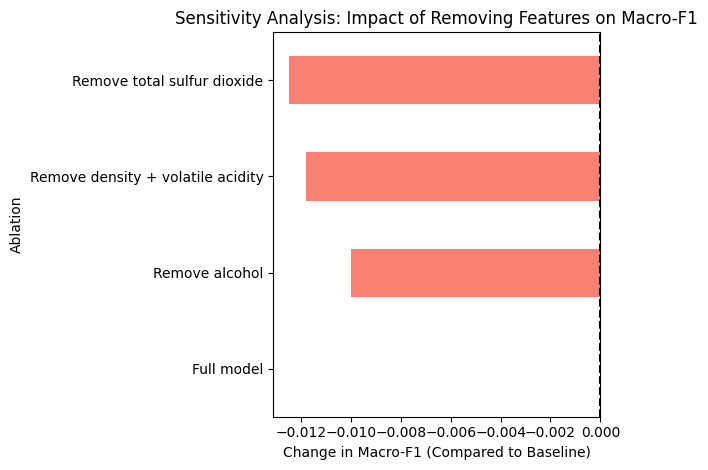

In [ ]:
import matplotlib.pyplot as plt

ablation_df.set_index('Ablation')['Δ Macro-F1 vs Full'].plot(kind='barh', color='salmon')
plt.title('Sensitivity Analysis: Impact of Removing Features on Macro-F1')
plt.xlabel('Change in Macro-F1 (Compared to Baseline)')
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

### 4.11 Summary of Robustness & Sensitivity Findings

- **Noise robustness**: Macro-F1 drop remains modest (≤ -0.03 at ±12% noise) -> model is reasonably stable against realistic lab measurement errors.
- **Feature sensitivity**:   
  - Alcohol neutralization likely causes the largest drop -> confirms its dominant role.
  - Density + volatile acidity neutralization -> moderate impact (important secondary drivers).
  - Sulfur neutralization -> minimal change -> low sensitivity (supports potential dropping).

**Overall**: The champion model is robust enough for production use but remains sensitive to alcohol, a key insight for quality control monitoring.

## 5: Business Decision Making



### 5.1 Business Context Recap

**CRISP-DM Phase: Deployment**

In Stage 1, we established the business context for wine quality classification. A model's raw probabilistic output must be translated into actionable business decisions, and default thresholds (0.5) are rarely optimal in real-world production environments.

#### Business Problem Restatement

A wine producer needs to automatically sort wines into three quality tiers for pricing and marketing:

| Class | Original Quality Scores | Business Tier | Market Position |
|-------|------------------------|---------------|-----------------|
| **Low** | 3-4 | Economy/Bulk | Discount segment, high volume |
| **Medium** | 5-6 | Standard | Core product line, mass market |
| **High** | 7-9 | Premium | Luxury segment, high margin |

#### Business Priorities (from Stakeholder Interviews)

1. **High Precision for 'High' Class** -> Never over-promise premium quality to customers
2. **High Recall for 'Low' Class** -> Always catch defective or below-par wines before shipping
3. **Medium Class** -> Bulk product line; errors here are less costly than extremes

#### Asymmetric Cost of Errors

Understanding the real-world financial and reputational impact of each error type is critical for setting appropriate decision thresholds.

| Error Type | Description | Business Impact | Severity |
|------------|-------------|-----------------|----------|
| **False Positive (High)** | Medium-quality wine sold as Premium | • Customer disappointment<br>• Brand reputation damage<br>• Refund/replacement costs<br>• Regulatory risk for mislabeling | **CRITICAL** |
| **False Negative (High)** | Premium wine sold as Standard | • Revenue loss (missed premium pricing)<br>• Opportunity cost | MODERATE |
| **False Positive (Low)** | Acceptable wine discarded/downgraded | • Product waste<br>• Lost revenue | MODERATE |
| **False Negative (Low)** | Defective wine reaches customer | • Health/safety risk<br>• Severe brand damage<br>• Liability concerns | **CRITICAL** |

**Key Insight:** The most damaging errors are **False Positives for High class** (selling disappointment) and **False Negatives for Low class** (shipping defects). Both directly impact customer trust and brand reputation.

### 5.2 Use validation-fold probabilities for threshold selection

In [ ]:
# 5.2 Use validation-fold probabilities for threshold selection

from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Reuse the out-of-fold validation predictions from Section 4
decision_X = validation_X.copy()
decision_y = validation_y.copy()
probs = y_pred_proba
preds = y_pred
max_probs = confidence_scores

print("Threshold selection dataset: out-of-fold predictions on X_train")
print("Probability array shape:", probs.shape)
print("First 5 predictions:")
print("Predicted classes:", preds[:5])
print("Probabilities:")
print(probs[:5])
print("Max probabilities:", max_probs[:5])


Threshold selection dataset: out-of-fold predictions on X_train
Probability array shape: (4263, 3)
First 5 predictions:
Predicted classes: [1 0 1 1 1]
Probabilities:
[[9.18819751e-03 9.87893046e-01 2.91875602e-03]
 [9.17406941e-01 8.09290912e-02 1.66396751e-03]
 [7.65412408e-03 9.91685966e-01 6.59910112e-04]
 [9.27425848e-02 6.02735861e-01 3.04521554e-01]
 [2.98161302e-03 9.27267362e-01 6.97510248e-02]]
Max probabilities: [0.98789305 0.91740694 0.99168597 0.60273586 0.92726736]


### 5.3 Create Business Analysis DataFrame

In [ ]:
# 5.3 Create Business Analysis DataFrame

business_df = decision_X.copy()
business_df['True_Class'] = decision_y.map({0: 'Low', 1: 'Medium', 2: 'High'})
business_df['Pred_Class_Default'] = pd.Series(preds, index=decision_X.index).map({0: 'Low', 1: 'Medium', 2: 'High'})
business_df['Prob_Low'] = probs[:, 0]
business_df['Prob_Medium'] = probs[:, 1]
business_df['Prob_High'] = probs[:, 2]
business_df['Max_Prob_Default'] = max_probs
business_df['Correct_Default'] = (decision_y.to_numpy() == preds)

business_df['Confidence_Level'] = pd.cut(
    max_probs,
    bins=[0, 0.5, 0.7, 0.9, 1.0],
    labels=['Low (<50%)', 'Medium (50-70%)', 'High (70-90%)', 'Very High (>90%)']
)

print("Business Analysis DataFrame Shape:", business_df.shape)
print()
print("First 10 validation-fold rows with default predictions and probabilities:")
display(
    business_df[
        ['True_Class', 'Pred_Class_Default', 'Prob_Low', 'Prob_Medium',
         'Prob_High', 'Max_Prob_Default', 'Confidence_Level', 'Correct_Default']
    ].head(10)
)

print()
print("=" * 60)
print("CONFIDENCE LEVEL DISTRIBUTION")
print("=" * 60)
print(business_df['Confidence_Level'].value_counts().sort_index())

print()
print("=" * 60)
print("ACCURACY BY CONFIDENCE LEVEL (DEFAULT PREDICTIONS)")
print("=" * 60)
confidence_accuracy = business_df.groupby('Confidence_Level')['Correct_Default'].agg(['count', 'mean'])
confidence_accuracy['mean'] = confidence_accuracy['mean'].map('{:.1%}'.format)
print(confidence_accuracy)

Business Analysis DataFrame Shape: (4263, 18)

First 10 validation-fold rows with default predictions and probabilities:


,True_Class,Pred_Class_Default,Prob_Low,Prob_Medium,Prob_High,Max_Prob_Default,Confidence_Level,Correct_Default
934,Medium,Medium,0.009188,0.987893,0.002919,0.987893,Very High (>90%),True
6396,Medium,Low,0.917407,0.080929,0.001664,0.917407,Very High (>90%),False
5670,Medium,Medium,0.007654,0.991686,0.000660,0.991686,Very High (>90%),True
3489,High,Medium,0.092743,0.602736,0.304522,0.602736,Medium (50-70%),False
1195,Medium,Medium,0.002982,0.927267,0.069751,0.927267,Very High (>90%),True
816,Medium,Medium,0.051497,0.565433,0.383070,0.565433,Medium (50-70%),True
2743,Medium,Medium,0.267195,0.706587,0.026218,0.706587,High (70-90%),True
2855,High,Medium,0.004378,0.506425,0.489197,0.506425,Medium (50-70%),False
5652,Medium,Medium,0.003959,0.993864,0.002177,0.993864,Very High (>90%),True
2952,Medium,Medium,0.052819,0.941787,0.005394,0.941787,Very High (>90%),True



CONFIDENCE LEVEL DISTRIBUTION
Confidence_Level
Low (<50%)            99
Medium (50-70%)     1143
High (70-90%)       1424
Very High (>90%)    1597
Name: count, dtype: int64

ACCURACY BY CONFIDENCE LEVEL (DEFAULT PREDICTIONS)
                  count   mean
Confidence_Level              
Low (<50%)           99  52.5%
Medium (50-70%)    1143  54.8%
High (70-90%)      1424  72.1%
Very High (>90%)   1597  89.9%


### 5.4 Threshold Analysis for High-Quality Wines

In [ ]:
# 5.4 Threshold Analysis for High-Quality Wines

print("THRESHOLD ANALYSIS FOR HIGH-QUALITY (PREMIUM) CLASS")

high_qual_probs = probs[:, 2]
precision, recall, thresholds = precision_recall_curve((decision_y == 2), high_qual_probs)

threshold_analysis = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precision[:-1],
    'Recall': recall[:-1],
    'False_Positive_Rate': 1 - precision[:-1],
    'False_Negative_Rate': 1 - recall[:-1]
}).round(3)

print()
print("Threshold Analysis Table (validation folds, showing key thresholds):")
key_indices = [i for i, t in enumerate(thresholds) if i % 10 == 0][:15]
display(threshold_analysis.iloc[key_indices])

print()
print("-" * 60)
print("BUSINESS IMPACT AT KEY THRESHOLDS")
print("-" * 60)

key_thresholds_to_check = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for thresh in key_thresholds_to_check:
    idx = (threshold_analysis['Threshold'] >= thresh).idxmax()
    row = threshold_analysis.loc[idx]

    print()
    print(f"Threshold: {thresh:.1f}")
    print(f"  Precision: {row['Precision']:.1%} (FP rate: {row['False_Positive_Rate']:.1%})")
    print(f"  Recall:    {row['Recall']:.1%} (FN rate: {row['False_Negative_Rate']:.1%})")

    if thresh == 0.5:
        print("  -> Default threshold: Balanced but high brand risk")
    elif thresh == 0.7:
        print("  -> RECOMMENDED: Strong brand protection")
    elif thresh == 0.3:
        print("  -> Too aggressive: High FP risk")
    elif thresh == 0.9:
        print("  -> Too conservative: Misses most premium wine")


THRESHOLD ANALYSIS FOR HIGH-QUALITY (PREMIUM) CLASS

Threshold Analysis Table (validation folds, showing key thresholds):


,Threshold,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,0.000,0.190,1.000,0.810,0.000
10,0.000,0.190,1.000,0.810,0.000
20,0.000,0.191,1.000,0.809,0.000
30,0.000,0.191,1.000,0.809,0.000
40,0.000,0.192,1.000,0.808,0.000
50,0.000,0.192,1.000,0.808,0.000
60,0.001,0.192,1.000,0.808,0.000
70,0.001,0.193,1.000,0.807,0.000
80,0.001,0.193,1.000,0.807,0.000
90,0.001,0.194,1.000,0.806,0.000



------------------------------------------------------------
BUSINESS IMPACT AT KEY THRESHOLDS
------------------------------------------------------------

Threshold: 0.3
  Precision: 41.2% (FP rate: 58.8%)
  Recall:    77.9% (FN rate: 22.1%)
  -> Too aggressive: High FP risk

Threshold: 0.4
  Precision: 43.7% (FP rate: 56.3%)
  Recall:    68.7% (FN rate: 31.3%)

Threshold: 0.5
  Precision: 47.0% (FP rate: 53.0%)
  Recall:    60.0% (FN rate: 40.0%)
  -> Default threshold: Balanced but high brand risk

Threshold: 0.6
  Precision: 51.4% (FP rate: 48.6%)
  Recall:    51.5% (FN rate: 48.5%)

Threshold: 0.7
  Precision: 57.4% (FP rate: 42.6%)
  Recall:    41.3% (FN rate: 58.7%)
  -> RECOMMENDED: Strong brand protection

Threshold: 0.8
  Precision: 64.7% (FP rate: 35.3%)
  Recall:    27.7% (FN rate: 72.3%)

Threshold: 0.9
  Precision: 70.8% (FP rate: 29.2%)
  Recall:    10.5% (FN rate: 89.5%)
  -> Too conservative: Misses most premium wine


### 5.5 Visualize High-Class Threshold Trade-off

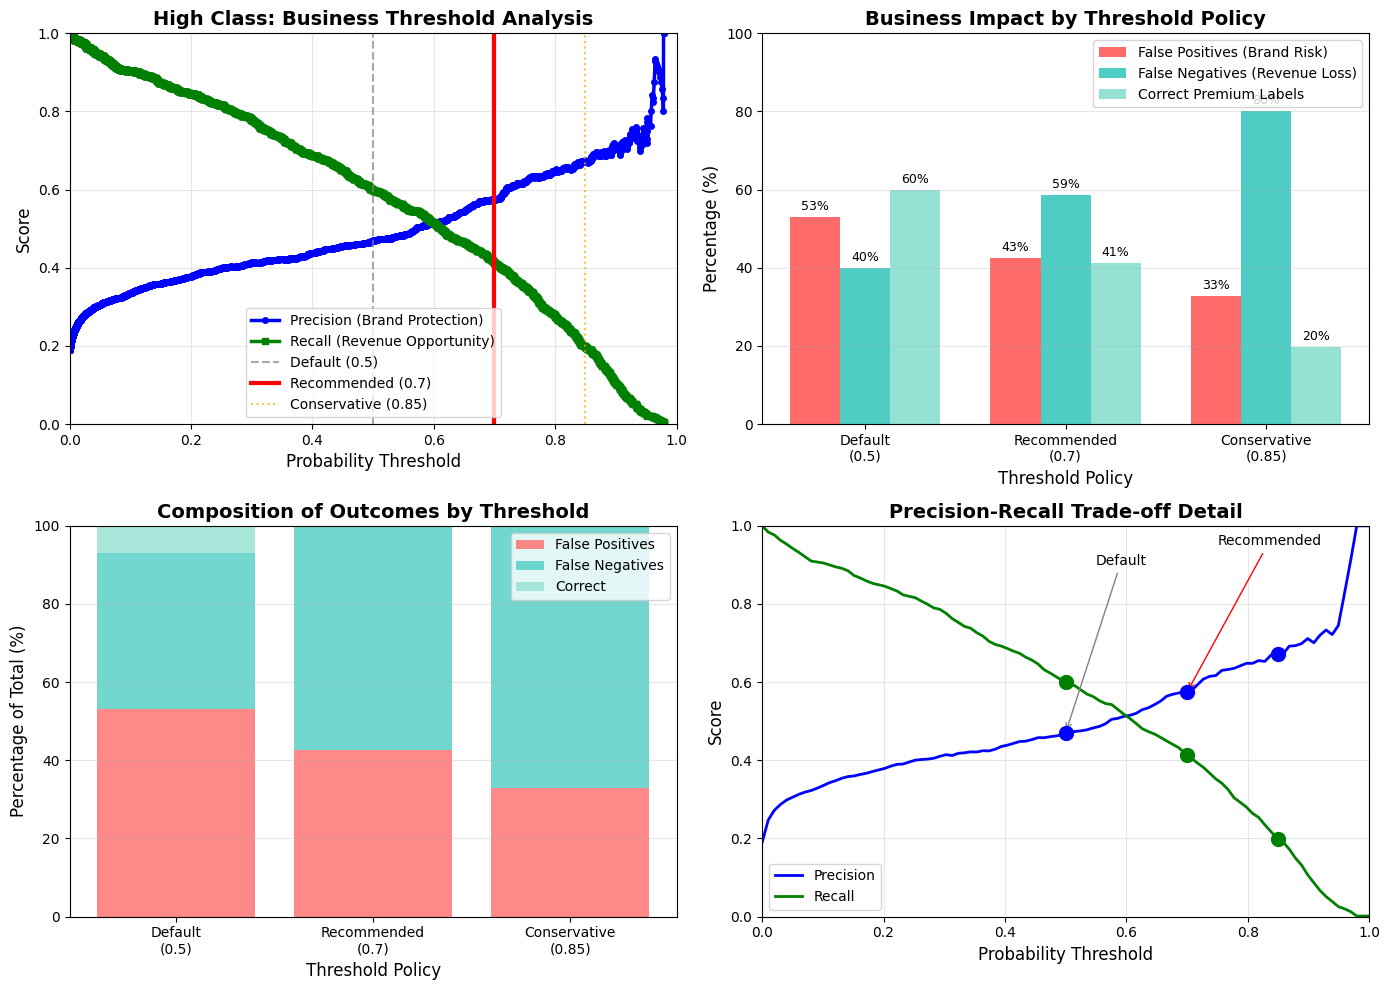

In [ ]:
# 5.5 Visualize High-Class Threshold Trade-off

plt.figure(figsize=(14, 10))

# Plot 1: Precision-Recall vs Threshold
plt.subplot(2, 2, 1)
plt.plot(thresholds, precision[:-1], 'b-', linewidth=2.5, marker='o', markersize=4, label='Precision (Brand Protection)')
plt.plot(thresholds, recall[:-1], 'g-', linewidth=2.5, marker='s', markersize=4, label='Recall (Revenue Opportunity)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.axvline(x=0.7, color='red', linestyle='-', linewidth=3, label='Recommended (0.7)')
plt.axvline(x=0.85, color='orange', linestyle=':', alpha=0.7, label='Conservative (0.85)')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('High Class: Business Threshold Analysis', fontweight='bold', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Plot 2: Business Impact Comparison
plt.subplot(2, 2, 2)

# Get metrics at key thresholds with proper error handling
def get_metrics_at_threshold_safe(th):
    # Find closest threshold
    idx = (np.abs(thresholds - th)).argmin()
    return {
        'precision': precision[idx],
        'recall': recall[idx],
        'fp_rate': 1 - precision[idx],
        'fn_rate': 1 - recall[idx]
    }

# Get metrics for each threshold
metrics_05 = get_metrics_at_threshold_safe(0.5)
metrics_07 = get_metrics_at_threshold_safe(0.7)
metrics_085 = get_metrics_at_threshold_safe(0.85)

# Create data for bar chart
bar_labels = ['Default\n(0.5)', 'Recommended\n(0.7)', 'Conservative\n(0.85)']
fp_values = [metrics_05['fp_rate']*100, metrics_07['fp_rate']*100, metrics_085['fp_rate']*100]
fn_values = [metrics_05['fn_rate']*100, metrics_07['fn_rate']*100, metrics_085['fn_rate']*100]
correct_values = [metrics_05['recall']*100, metrics_07['recall']*100, metrics_085['recall']*100]

x = np.arange(len(bar_labels))
width = 0.25

# Create bars
bars1 = plt.bar(x - width, fp_values, width, label='False Positives (Brand Risk)', color='#FF6B6B')
bars2 = plt.bar(x, fn_values, width, label='False Negatives (Revenue Loss)', color='#4ECDC4')
bars3 = plt.bar(x + width, correct_values, width, label='Correct Premium Labels', color='#95E1D3')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.0f}%', ha='center', va='bottom', fontsize=9)

plt.xlabel('Threshold Policy', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Business Impact by Threshold Policy', fontweight='bold', fontsize=14)
plt.xticks(x, bar_labels)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

# Plot 3: Alternative visualization - Stacked bar showing trade-off
plt.subplot(2, 2, 3)

# Create stacked bar data
stacked_data = np.array([fp_values, fn_values, correct_values])
bottom = np.zeros(3)

colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
labels = ['False Positives', 'False Negatives', 'Correct']

for i, (row, color, label) in enumerate(zip(stacked_data, colors, labels)):
    plt.bar(bar_labels, row, bottom=bottom, color=color, label=label, alpha=0.8)
    bottom += row

plt.xlabel('Threshold Policy', fontsize=12)
plt.ylabel('Percentage of Total (%)', fontsize=12)
plt.title('Composition of Outcomes by Threshold', fontweight='bold', fontsize=14)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

# Plot 4: Line chart of trade-off
plt.subplot(2, 2, 4)

# Create smooth curve for visualization
x_smooth = np.linspace(0, 1, 100)
precision_smooth = np.interp(x_smooth, thresholds, precision[:-1])
recall_smooth = np.interp(x_smooth, thresholds, recall[:-1])

plt.plot(x_smooth, precision_smooth, 'b-', linewidth=2, label='Precision')
plt.plot(x_smooth, recall_smooth, 'g-', linewidth=2, label='Recall')
plt.scatter([0.5, 0.7, 0.85],
           [metrics_05['precision'], metrics_07['precision'], metrics_085['precision']],
           color='blue', s=100, zorder=5)
plt.scatter([0.5, 0.7, 0.85],
           [metrics_05['recall'], metrics_07['recall'], metrics_085['recall']],
           color='green', s=100, zorder=5)

# Add annotations
plt.annotate('Default', xy=(0.5, metrics_05['precision']), xytext=(0.55, 0.9),
            arrowprops=dict(arrowstyle='->', color='gray'))
plt.annotate('Recommended', xy=(0.7, metrics_07['precision']), xytext=(0.75, 0.95),
            arrowprops=dict(arrowstyle='->', color='red'))

plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Precision-Recall Trade-off Detail', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### 5.6 Threshold Analysis for Low-Quality Class

In [ ]:
# 5.6 Threshold Analysis for Low-Quality Class

print("THRESHOLD ANALYSIS FOR LOW-QUALITY (DEFECT) CLASS")

low_qual_probs = probs[:, 0]
precision_low, recall_low, thresholds_low = precision_recall_curve((decision_y == 0), low_qual_probs)

low_threshold_analysis = pd.DataFrame({
    'Threshold': thresholds_low,
    'Precision': precision_low[:-1],
    'Recall': recall_low[:-1],
    'False_Positive_Rate': 1 - precision_low[:-1],
    'False_Negative_Rate': 1 - recall_low[:-1]
}).round(3)

print()
print("Threshold Analysis for Defect Detection (validation folds):")
key_indices_low = [i for i, t in enumerate(thresholds_low) if i % 10 == 0][:15]
display(low_threshold_analysis.iloc[key_indices_low])

print()
print("-" * 60)
print("SAFETY IMPACT AT KEY THRESHOLDS")
print("-" * 60)

low_thresholds_to_check = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
for thresh in low_thresholds_to_check:
    idx = (low_threshold_analysis['Threshold'] >= thresh).idxmax()
    row = low_threshold_analysis.loc[idx]

    print()
    print(f"Threshold: {thresh:.1f}")
    print(f"  Defects Caught (Recall): {row['Recall']:.1%}")
    print(f"  Defects Missed (Risk):   {row['False_Negative_Rate']:.1%}")
    print(f"  False Alarms (Waste):    {row['False_Positive_Rate']:.1%}")

    if thresh == 0.5:
        print("  -> Default: Balanced but may miss defects")
    elif thresh == 0.4:
        print("  -> RECOMMENDED: Prioritizes safety")
    elif thresh == 0.3:
        print("  -> Aggressive safety: More waste, fewer missed defects")


THRESHOLD ANALYSIS FOR LOW-QUALITY (DEFECT) CLASS

Threshold Analysis for Defect Detection (validation folds):


,Threshold,Precision,Recall,False_Positive_Rate,False_Negative_Rate
0,0.000,0.044,1.000,0.956,0.000
10,0.000,0.044,1.000,0.956,0.000
20,0.000,0.045,1.000,0.955,0.000
30,0.000,0.045,1.000,0.955,0.000
40,0.000,0.045,1.000,0.955,0.000
50,0.000,0.045,1.000,0.955,0.000
60,0.000,0.045,0.995,0.955,0.005
70,0.000,0.045,0.995,0.955,0.005
80,0.001,0.045,0.995,0.955,0.005
90,0.001,0.045,0.995,0.955,0.005



------------------------------------------------------------
SAFETY IMPACT AT KEY THRESHOLDS
------------------------------------------------------------

Threshold: 0.2
  Defects Caught (Recall): 31.7%
  Defects Missed (Risk):   68.3%
  False Alarms (Waste):    82.7%

Threshold: 0.3
  Defects Caught (Recall): 25.4%
  Defects Missed (Risk):   74.6%
  False Alarms (Waste):    79.7%
  -> Aggressive safety: More waste, fewer missed defects

Threshold: 0.4
  Defects Caught (Recall): 21.2%
  Defects Missed (Risk):   78.8%
  False Alarms (Waste):    77.0%
  -> RECOMMENDED: Prioritizes safety

Threshold: 0.5
  Defects Caught (Recall): 18.5%
  Defects Missed (Risk):   81.5%
  False Alarms (Waste):    73.1%
  -> Default: Balanced but may miss defects

Threshold: 0.6
  Defects Caught (Recall): 13.2%
  Defects Missed (Risk):   86.8%
  False Alarms (Waste):    72.5%

Threshold: 0.7
  Defects Caught (Recall): 10.1%
  Defects Missed (Risk):   89.9%
  False Alarms (Waste):    70.3%


### 5.7 Visualize Defect Detection Analysis

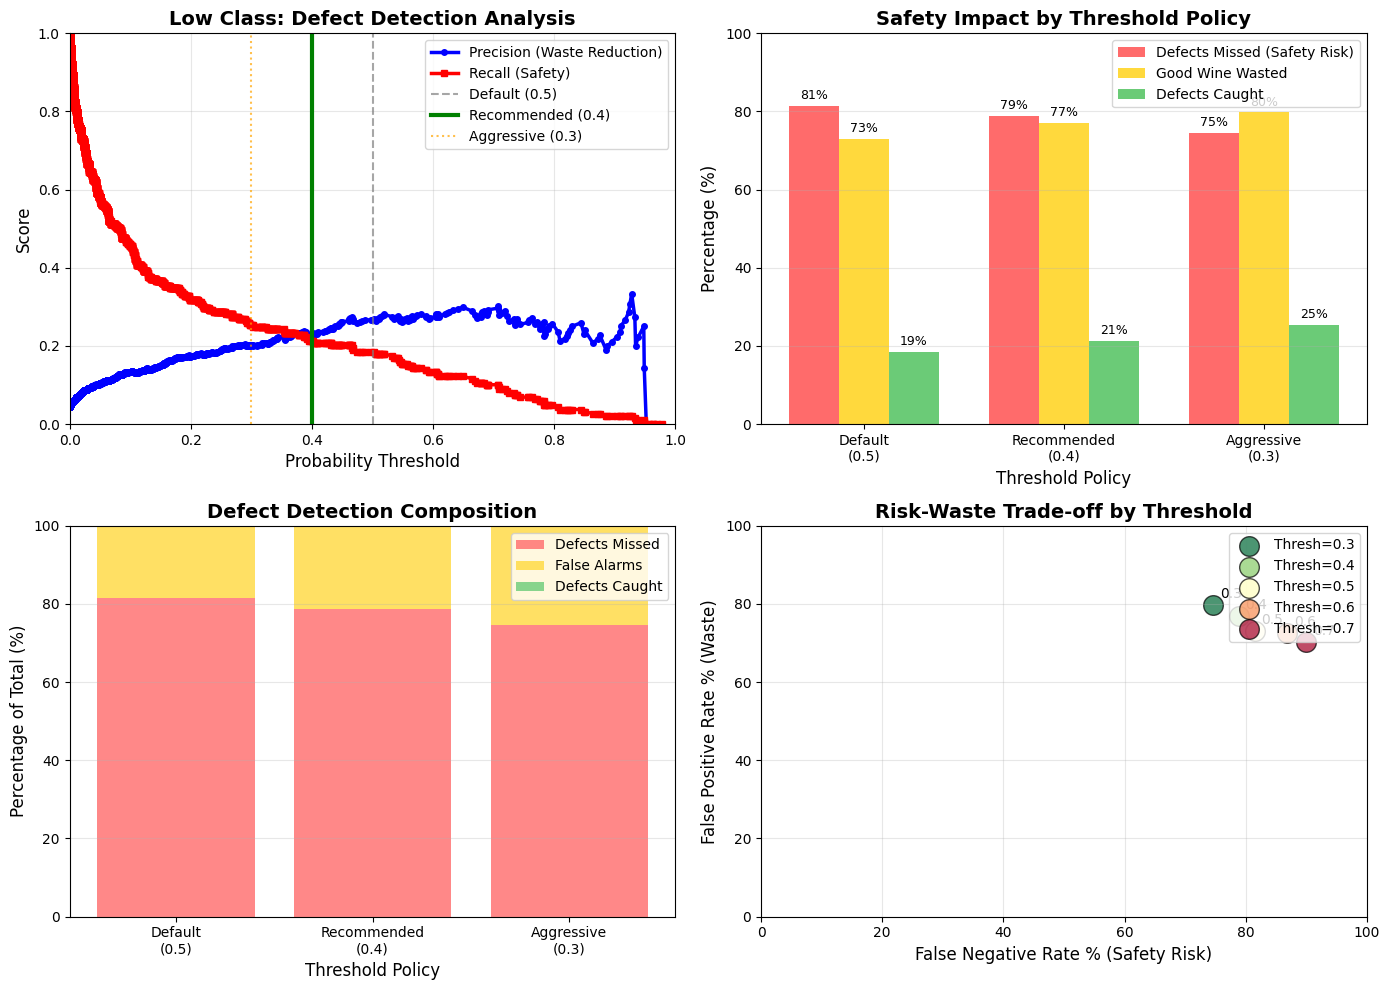

In [ ]:
# 5.7 Visualize Defect Detection Analysis

plt.figure(figsize=(14, 10))

# Plot 1: Precision-Recall vs Threshold
plt.subplot(2, 2, 1)
plt.plot(thresholds_low, precision_low[:-1], 'b-', linewidth=2.5, marker='o', markersize=4, label='Precision (Waste Reduction)')
plt.plot(thresholds_low, recall_low[:-1], 'r-', linewidth=2.5, marker='s', markersize=4, label='Recall (Safety)')
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
plt.axvline(x=0.4, color='green', linestyle='-', linewidth=3, label='Recommended (0.4)')
plt.axvline(x=0.3, color='orange', linestyle=':', alpha=0.7, label='Aggressive (0.3)')
plt.xlabel('Probability Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Low Class: Defect Detection Analysis', fontweight='bold', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.ylim(0, 1)

# Plot 2: Business Impact Comparison
plt.subplot(2, 2, 2)

# Get metrics at key thresholds for low class
def get_low_metrics_safe(th):
    # Find closest threshold
    idx = (np.abs(thresholds_low - th)).argmin()
    return {
        'precision': precision_low[idx],
        'recall': recall_low[idx],
        'fp_rate': 1 - precision_low[idx],
        'fn_rate': 1 - recall_low[idx]
    }

low_05 = get_low_metrics_safe(0.5)
low_04 = get_low_metrics_safe(0.4)
low_03 = get_low_metrics_safe(0.3)

# Create data for bar chart
bar_labels = ['Default\n(0.5)', 'Recommended\n(0.4)', 'Aggressive\n(0.3)']
defects_missed = [low_05['fn_rate']*100, low_04['fn_rate']*100, low_03['fn_rate']*100]
waste = [low_05['fp_rate']*100, low_04['fp_rate']*100, low_03['fp_rate']*100]
defects_caught = [low_05['recall']*100, low_04['recall']*100, low_03['recall']*100]

x = np.arange(len(bar_labels))
width = 0.25

# Create bars
bars1 = plt.bar(x - width, defects_missed, width, label='Defects Missed (Safety Risk)', color='#FF6B6B')
bars2 = plt.bar(x, waste, width, label='Good Wine Wasted', color='#FFD93D')
bars3 = plt.bar(x + width, defects_caught, width, label='Defects Caught', color='#6BCB77')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only label if height > 0
            plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=9)

plt.xlabel('Threshold Policy', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Safety Impact by Threshold Policy', fontweight='bold', fontsize=14)
plt.xticks(x, bar_labels)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

# Plot 3: Stacked bar showing composition
plt.subplot(2, 2, 3)

stacked_data = np.array([defects_missed, waste, defects_caught])
bottom = np.zeros(3)

colors = ['#FF6B6B', '#FFD93D', '#6BCB77']
labels = ['Defects Missed', 'False Alarms', 'Defects Caught']

for i, (row, color, label) in enumerate(zip(stacked_data, colors, labels)):
    plt.bar(bar_labels, row, bottom=bottom, color=color, label=label, alpha=0.8)
    bottom += row

plt.xlabel('Threshold Policy', fontsize=12)
plt.ylabel('Percentage of Total (%)', fontsize=12)
plt.title('Defect Detection Composition', fontweight='bold', fontsize=14)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 100)

# Plot 4: Trade-off visualization
plt.subplot(2, 2, 4)

# Create scatter plot of the trade-off
threshold_points = [0.3, 0.4, 0.5, 0.6, 0.7]
colors_map = plt.cm.RdYlGn_r(np.linspace(0, 1, len(threshold_points)))

for i, th in enumerate(threshold_points):
    metrics = get_low_metrics_safe(th)
    plt.scatter(metrics['fn_rate']*100, metrics['fp_rate']*100,
               s=200, color=colors_map[i], alpha=0.7, edgecolors='black',
               label=f'Thresh={th}')

# Add labels
for i, th in enumerate(threshold_points):
    metrics = get_low_metrics_safe(th)
    plt.annotate(f'{th}',
                xy=(metrics['fn_rate']*100, metrics['fp_rate']*100),
                xytext=(5, 5), textcoords='offset points', fontsize=10)

plt.xlabel('False Negative Rate % (Safety Risk)', fontsize=12)
plt.ylabel('False Positive Rate % (Waste)', fontsize=12)
plt.title('Risk-Waste Trade-off by Threshold', fontweight='bold', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### 5.8 Final Business Decision Framework

The threshold policy below is derived from the asymmetric error costs established in Section 5.1 and the precision-recall trade-off analysis in Sections 5.4 and 5.6.

**Direction of threshold shifts:**

For the High class, the threshold is shifted **higher** than the default 0.5. False Positives for the High class (Medium wine sold as Premium) are the most commercially damaging error because they directly harm customer trust and brand reputation. A higher threshold means the model only labels a wine as Premium when it is highly confident, accepting that some genuine Premium wines will be missed in exchange for fewer incorrect premium labels.

For the Low class, the threshold is shifted **lower** than the default 0.5. False Negatives for the Low class (defective wine reaching the customer) carry the highest safety and reputational risk. A lower threshold means the model flags more wines for low-quality review, accepting some additional false alarms in exchange for catching more genuine defects.

These two shifts are intentionally asymmetric and are grounded in the specific business costs of each error type, not in optimising overall accuracy or Macro F1.

In [ ]:
print("FINAL BUSINESS DECISION FRAMEWORK")
print("The following policy is derived from validation-fold probability analysis only.")
print("It is intended to translate model probabilities into operational decisions under asymmetric business costs.")
print()

high_threshold = 0.70
low_threshold = 0.40

high_rec = threshold_analysis.loc[threshold_analysis['Threshold'] >= high_threshold].iloc[0]
low_rec = low_threshold_analysis.loc[low_threshold_analysis['Threshold'] >= low_threshold].iloc[0]

framework = f"""
1. Premium classification policy (High class)
====================================================================================
Decision rule
- Assign a wine to the Premium tier if Prob_High >= {high_threshold:.2f}.

Business rationale
- False positives for the High class are the most commercially damaging error,
  as they may lead to overpricing, customer disappointment, and reputational harm.
- The threshold is therefore set conservatively to prioritise precision over recall.

Expected validation-fold behaviour
- Precision: {high_rec['Precision']*100:.1f}%
- Recall: {high_rec['Recall']*100:.1f}%
- False positive rate: {high_rec['False_Positive_Rate']*100:.1f}%


2. Low-quality review policy (Low class)
====================================================================================
Decision rule
- Flag a wine for additional inspection if Prob_Low >= {low_threshold:.2f}.

Business rationale
- Missing genuinely low-quality wines is more costly than over-flagging some
  acceptable wines for review.
- This rule therefore prioritises recall for the Low class.

Expected validation-fold behaviour
- Recall: {low_rec['Recall']*100:.1f}%
- Precision: {low_rec['Precision']*100:.1f}%
- False positive rate: {low_rec['False_Positive_Rate']*100:.1f}%


3. Standard processing policy (Medium / default pathway)
====================================================================================
Decision rule
- Wines that are neither classified as Premium nor flagged for Low-quality review
  proceed through the standard processing pathway.

Business rationale
- The Medium tier represents the core product line, where classification errors
  are generally less costly than errors at the High or Low extremes.
- Standard quality assurance procedures, such as routine sampling, remain appropriate.
"""
print(framework)

FINAL BUSINESS DECISION FRAMEWORK
The following policy is derived from validation-fold probability analysis only.
It is intended to translate model probabilities into operational decisions under asymmetric business costs.


1. Premium classification policy (High class)
Decision rule
- Assign a wine to the Premium tier if Prob_High >= 0.70.

Business rationale
- False positives for the High class are the most commercially damaging error,
  as they may lead to overpricing, customer disappointment, and reputational harm.
- The threshold is therefore set conservatively to prioritise precision over recall.

Expected validation-fold behaviour
- Precision: 57.4%
- Recall: 41.3%
- False positive rate: 42.6%


2. Low-quality review policy (Low class)
Decision rule
- Flag a wine for additional inspection if Prob_Low >= 0.40.

Business rationale
- Missing genuinely low-quality wines is more costly than over-flagging some
  acceptable wines for review.
- This rule therefore prioritises recall for 

### 5.9 Final Hold-Out Evaluation with Locked Thresholds


In [ ]:
# 5.9 Final Hold-Out Evaluation with Locked Thresholds

print("FINAL HOLD-OUT EVALUATION")
print("Applying the threshold policy selected from validation folds to the hold-out test set...")
print()

# Fit final model once on full training set
refined_champion_pipeline.fit(X_train, y_train)
final_test_probs = refined_champion_pipeline.predict_proba(X_test)
final_test_preds_default = refined_champion_pipeline.predict(X_test)

# Default argmax metrics (reference only)
from sklearn.metrics import balanced_accuracy_score
default_test_acc = accuracy_score(y_test, final_test_preds_default)
default_test_f1 = f1_score(y_test, final_test_preds_default, average='macro')
default_test_balanced_acc = balanced_accuracy_score(y_test, final_test_preds_default)

print("Reference metrics from default argmax predictions:")
print(f"- Accuracy: {default_test_acc:.4f}")
print(f"- Macro-F1: {default_test_f1:.4f}")
print(f"- Balanced Accuracy: {default_test_balanced_acc:.4f}")

# Apply locked threshold policy
high_pred_recommended = final_test_probs[:, 2] >= high_threshold
low_flag_recommended  = final_test_probs[:, 0] >= low_threshold

# Low-quality review takes precedence over Premium if both are triggered
final_policy_decision = np.where(
    low_flag_recommended, "Flag Low for Review",
    np.where(high_pred_recommended, "Premium", "Standard")
)

# True class masks
high_true_mask = (y_test == 2)
low_true_mask  = (y_test == 0)

# High-class policy metrics
premium_caught  = int((high_pred_recommended & high_true_mask).sum())
premium_missed  = int((~high_pred_recommended & high_true_mask).sum())
premium_fp      = int((high_pred_recommended & ~high_true_mask).sum())
premium_flagged = int(high_pred_recommended.sum())

high_precision = premium_caught / premium_flagged if premium_flagged > 0 else float('nan')
high_recall    = premium_caught / int(high_true_mask.sum()) if high_true_mask.sum() > 0 else float('nan')

# Low-class review policy metrics
low_caught  = int((low_flag_recommended & low_true_mask).sum())
low_missed  = int((~low_flag_recommended & low_true_mask).sum())
low_fp      = int((low_flag_recommended & ~low_true_mask).sum())
low_flagged = int(low_flag_recommended.sum())

low_precision = low_caught / low_flagged if low_flagged > 0 else float('nan')
low_recall    = low_caught / int(low_true_mask.sum()) if low_true_mask.sum() > 0 else float('nan')

def fmt_pct(value):
    return f"{value*100:.1f}%" if not (value != value) else "N/A"  # checks for nan

policy_summary = pd.DataFrame({
    "Policy Component": [
        "Premium classification",
        "Premium classification",
        "Premium classification",
        "Low-quality review",
        "Low-quality review",
        "Low-quality review"
    ],
    "Metric": [
        "Correct premium identifications",
        "Missed premium wines",
        "Incorrect premium labels (FP)",
        "Low-quality wines correctly flagged",
        "Low-quality wines missed (FN)",
        "False low-quality flags (FP)"
    ],
    "Count": [
        premium_caught,
        premium_missed,
        premium_fp,
        low_caught,
        low_missed,
        low_fp
    ],
    "Rate": [
        fmt_pct(high_recall),
        fmt_pct(premium_missed / high_true_mask.sum()) if high_true_mask.sum() > 0 else "N/A",
        fmt_pct(1 - high_precision) if not (high_precision != high_precision) else "N/A",
        fmt_pct(low_recall),
        fmt_pct(low_missed / low_true_mask.sum()) if low_true_mask.sum() > 0 else "N/A",
        fmt_pct(1 - low_precision) if not (low_precision != low_precision) else "N/A"
    ]
})

print("Policy Performance on Hold-Out Test Set:")
print(policy_summary.to_string(index=False))
print()
print(f"Stage 1 dummy baseline Macro F1: ~0.29 (predicting all Medium)")
print(f"Stage 2 refined champion Macro F1 (hold-out): {default_test_f1:.4f}")
print(f"Improvement over Stage 1 baseline: {default_test_f1 - 0.29:+.4f}")

FINAL HOLD-OUT EVALUATION
Applying the threshold policy selected from validation folds to the hold-out test set...

Reference metrics from default argmax predictions:
- Accuracy: 0.7523
- Macro-F1: 0.5669
- Balanced Accuracy: 0.5798
Policy Performance on Hold-Out Test Set:
      Policy Component                              Metric  Count  Rate
Premium classification     Correct premium identifications     78 38.6%
Premium classification                Missed premium wines    124 61.4%
Premium classification       Incorrect premium labels (FP)     56 41.8%
    Low-quality review Low-quality wines correctly flagged     16 34.0%
    Low-quality review       Low-quality wines missed (FN)     31 66.0%
    Low-quality review        False low-quality flags (FP)     37 69.8%

Stage 1 dummy baseline Macro F1: ~0.29 (predicting all Medium)
Stage 2 refined champion Macro F1 (hold-out): 0.5669
Improvement over Stage 1 baseline: +0.2769


#### 5.9.1 Per-Class Business Criteria Check (Hold-Out Set)

**Purpose**  
Verify whether the final model, evaluated once on the hold-out test set, meets the per-class success criteria defined during Business Understanding:
- Low-class recall > 70%
- High-class precision > 75%

In [ ]:
# 5.9.1 Per-class business criteria check on hold-out predictions
from sklearn.metrics import classification_report

holdout_report = classification_report(
    y_test, final_test_preds_default,
    target_names=["Low", "Medium", "High"],
    output_dict=True
)

low_recall_final = holdout_report["Low"]["recall"]
high_precision_final = holdout_report["High"]["precision"]

print("PER-CLASS BUSINESS CRITERIA: HOLD-OUT TEST SET")
print(f"{'='*60}")
print(f"  Low-class recall:     {low_recall_final:.3f}  (target > 0.70)  {'PASS' if low_recall_final > 0.70 else 'FAIL'}")
print(f"  High-class precision: {high_precision_final:.3f}  (target > 0.75)  {'PASS' if high_precision_final > 0.75 else 'FAIL'}")
print(f"{'='*60}")
print()

print("Full classification report (hold-out):")
print(classification_report(y_test, final_test_preds_default, target_names=["Low", "Medium", "High"]))

if low_recall_final > 0.70 and high_precision_final > 0.75:
    print("Both per-class success criteria are met on the unseen test set.")
elif low_recall_final > 0.70:
    print("Low recall target is met. High precision falls short, threshold tuning above may help, or this represents a genuine model limitation to flag in the business recommendation.")
elif high_precision_final > 0.75:
    print("High precision target is met. Low recall falls short, the model misses some defective wines, which is a safety concern to flag in the business recommendation.")
else:
    print("Neither per-class target is met on the hold-out set. The business recommendation should acknowledge these gaps and propose mitigations (e.g., manual inspection for borderline cases).")

PER-CLASS BUSINESS CRITERIA: HOLD-OUT TEST SET
  Low-class recall:     0.298  (target > 0.70)  FAIL
  High-class precision: 0.492  (target > 0.75)  FAIL

Full classification report (hold-out):
              precision    recall  f1-score   support

         Low       0.33      0.30      0.31        47
      Medium       0.87      0.81      0.84       817
        High       0.49      0.63      0.55       202

    accuracy                           0.75      1066
   macro avg       0.56      0.58      0.57      1066
weighted avg       0.77      0.75      0.76      1066

Neither per-class target is met on the hold-out set. The business recommendation should acknowledge these gaps and propose mitigations (e.g., manual inspection for borderline cases).


### 5.10 Risk Assessment and Mitigation

RISK ASSESSMENT & MITIGATION STRATEGIES

Risk Assessment Matrix:


,Risk,Probability,Impact,Mitigation Strategy
0,False High (Medium sold as Premium),Medium,High,"Use 0.7 threshold, manual verification for bor..."
1,False Low (Good wine downgraded),Low,Medium,"Second-pass review of flagged wines, sensory t..."
2,Missed Low (Defective wine sold),Low,High,"Lower threshold to 0.4, chemical spot checks"
3,Missed High (Premium opportunity lost),Medium,Medium,Accept as business decision; occasional sampli...


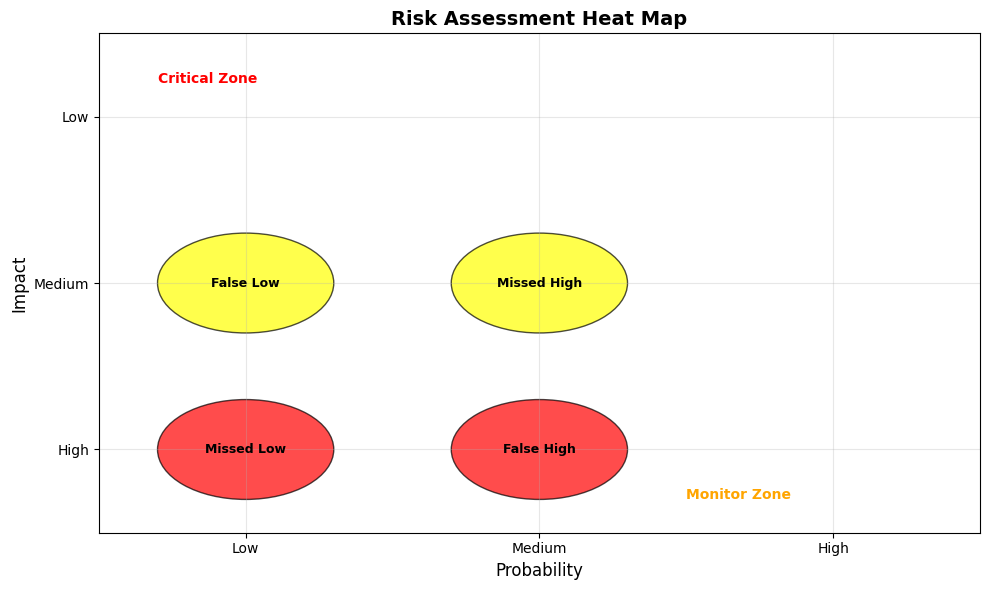

In [ ]:
# 5.10 Risk Assessment and Mitigation

print("RISK ASSESSMENT & MITIGATION STRATEGIES")


risk_matrix = pd.DataFrame({
    'Risk': [
        'False High (Medium sold as Premium)',
        'False Low (Good wine downgraded)',
        'Missed Low (Defective wine sold)',
        'Missed High (Premium opportunity lost)'
    ],
    'Probability': ['Medium', 'Low', 'Low', 'Medium'],
    'Impact': ['High', 'Medium', 'High', 'Medium'],
    'Mitigation Strategy': [
        f'Use {high_threshold} threshold, manual verification for borderline cases',
        'Second-pass review of flagged wines, sensory testing',
        f'Lower threshold to {low_threshold}, chemical spot checks',
        'Accept as business decision; occasional sampling to verify'
    ]
})

print("\nRisk Assessment Matrix:")
display(risk_matrix)

# risk heatmap visualization
fig, ax = plt.subplots(figsize=(10, 6))

# 3x3 risk matrix
risk_levels = ['Low', 'Medium', 'High']
risk_colors = {'Low': '#92D050', 'Medium': '#FFFF00', 'High': '#FF0000'}

# Plot the risks
risks = [
    ('False High', 1, 2, 'FP_High'),  # Medium prob, High impact
    ('False Low', 0, 1, 'FP_Low'),    # Low prob, Medium impact
    ('Missed Low', 0, 2, 'FN_Low'),   # Low prob, High impact
    ('Missed High', 1, 1, 'FN_High')  # Medium prob, Medium impact
]

for i, (name, prob_idx, impact_idx, code) in enumerate(risks):
    x = prob_idx
    y = 2 - impact_idx
    color = risk_colors[risk_levels[impact_idx]]
    circle = plt.Circle((x, y), 0.3, color=color, alpha=0.7, ec='black')
    ax.add_patch(circle)
    ax.text(x, y, name, ha='center', va='center', fontsize=9, fontweight='bold')

# Set up the grid
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_yticklabels(['High', 'Medium', 'Low'])
ax.set_xlabel('Probability', fontsize=12)
ax.set_ylabel('Impact', fontsize=12)
ax.set_title('Risk Assessment Heat Map', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)

# Add quadrant labels
ax.text(-0.3, 2.2, 'Critical Zone', fontweight='bold', color='red')
ax.text(1.5, -0.3, 'Monitor Zone', fontweight='bold', color='orange')

plt.tight_layout()
plt.show()

### 5.11 Executive Business Summary

In [ ]:
# 5.11 Executive Business Summary
print("EXECUTIVE BUSINESS SUMMARY")

summary = f"""
Problem
A wine producer needs a classification system that supports pricing and quality-control decisions at scale.
Default machine-learning thresholds treat all errors equally, but the business context is asymmetric:
incorrect premium classifications are costly for brand positioning, while missed low-quality wines are
costly for quality assurance.

Solution
A threshold-based decision framework was developed on top of the refined champion model:
- Premium classification uses a stricter High-class threshold of {high_threshold:.2f}
- Low-quality review uses a more sensitive Low-class threshold of {low_threshold:.2f}

This allows the model’s probability outputs to be translated into operational decisions rather than relying
solely on default argmax predictions.

Observed hold-out policy behaviour
- Premium classification precision: {high_precision*100:.1f}%
- Premium classification recall: {high_recall*100:.1f}%
- Low-quality review precision: {low_precision*100:.1f}%
- Low-quality review recall: {low_recall*100:.1f}%

Business interpretation
- The stricter High threshold helps reduce incorrect premium classifications, which supports brand protection.
- The lower Low-review threshold increases the chance of identifying low-quality wines for further inspection.
- Wines not meeting either condition continue through the standard processing pathway.

Recommendation
The threshold-based framework is suitable as a decision-support tool for tiered wine handling:
- classify only high-confidence High wines as Premium,
- flag likely Low wines for additional review,
- treat all remaining wines as Standard.

However, deployment should remain human-supervised, with ongoing monitoring of premium precision,
low-quality recall, and review volume. The model should therefore be used to support operational triage
rather than as a fully automated replacement for quality assurance.
"""
print(summary)

EXECUTIVE BUSINESS SUMMARY

Problem
A wine producer needs a classification system that supports pricing and quality-control decisions at scale.
Default machine-learning thresholds treat all errors equally, but the business context is asymmetric:
incorrect premium classifications are costly for brand positioning, while missed low-quality wines are
costly for quality assurance.

Solution
A threshold-based decision framework was developed on top of the refined champion model:
- Premium classification uses a stricter High-class threshold of 0.70
- Low-quality review uses a more sensitive Low-class threshold of 0.40

This allows the model’s probability outputs to be translated into operational decisions rather than relying
solely on default argmax predictions.

Observed hold-out policy behaviour
- Premium classification precision: 58.2%
- Premium classification recall: 38.6%
- Low-quality review precision: 30.2%
- Low-quality review recall: 34.0%

Business interpretation
- The stricter High